# EDA & Machine Learning: Heart Disease Prevalence (Socio-demographic Data)

## Paso 0: **Imports**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import pickle
import os
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# **EDA**

## Paso 1: **Lectura de la data**

In [3]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## PASO 2: **Exploracion de los datos**

> * **Planteamiento:** Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.  
Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.
> * **Objetivo:** Para este modelo quiero analizar la relación de la prevalencia del cancer según los datos demográficos.  
> * **Variable target** 
> ``Hear disease_prevalence``, variable target escogida ya que nos indica la prevalencia de la enfermedad sin especificar cuál.

###  **Información de los datos:**

In [4]:
df.shape

(3140, 108)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [6]:
df.info

<bound method DataFrame.info of        fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0      1001    55601   6787               12.206615    7637   
1      1003   218022  24757               11.355276   26913   
2      1005    24881   2732               10.980266    2960   
3      1007    22400   2456               10.964286    2596   
4      1009    57840   7095               12.266598    7570   
...     ...      ...    ...                     ...     ...   
3135  56037    43051   6104               14.178532    6326   
3136  56039    23081   2384               10.328842    2185   
3137  56041    20299   3121               15.375142    3205   
3138  56043     7885    858               10.881420    1113   
3139  56045     6967    780               11.195637     779   

      10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                    13.735364   6878                 12.370281   7089   
1                    12.344167  23579                 10.814964

> **Observaciones:**
> * Contiene 3140 filas y 108 columnas  
> * Los datos que aporta el datset son 106 columnas de tipo numérico (enteros y decimales) y 2 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(61), int64(45), object(2)``  

## PASO 3: **Limpieza de datos**

In [7]:
df.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='str', length=108)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Compruebo si hay datos nulos (datos faltantes)
df.isna().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

> **Conclusión de la limpieza de datos:**
> Las columnas no contienen valores nulos ni duplicados.

In [10]:
df['COUNTY_NAME'].nunique()

1841

In [11]:
df['STATE_NAME'].nunique()

51

In [12]:
df = df.drop(["STATE_NAME","COUNTY_NAME"], axis=1) # Son variables identificadoras y no aportan información predictiva

> **Conclusión de limpieza:** Se eliminaron variables que representaban distribuciones demográficas redundantes o agregadas de población, ya que introducen colinealidad y no aportan información adicional relevante para el modelo.

### **Descripción de las variables y conclusiones de la primera limpieza de datos**

1. **Identificadores geográficos:** Estas variables identifican la localización geográfica de cada registro.

* fips → Código FIPS del condado (identificador único utilizado por el gobierno de EE.UU.)

* STATE_FIPS → Código FIPS del estado

* county_name → Nombre del condado

* state_name → Nombre del estado

* cnty_fips → Código FIPS del condado en formato alternativo

**Decisiones de limpieza:** Se eliminan county_name, state_name y cnty_fips porque son variables redundantes o categóricas que no aportan valor al modelo y se mantiene STATE_FIPS para conservar un indicador geográfico numérico que permita identificar la localización del registro.

2. **Población total y por edad:** El dataset contiene múltiples variables relacionadas con la distribución de la población por grupos de edad. Generalmente aparecen en dos formatos:

**Número absoluto de personas y porcentaje sobre la población total:**

0-9 → Número de personas entre 0 y 9 años

0-9 % of total pop → Porcentaje de población entre 0 y 9 años

**Este patrón se repite para varios rangos de edad:**

* 0–9

* 10–19

* 20–29

* 30–39

* 40–49

* 50–59

* 60–69

* 70–79

* 80+

**Decisiones de limpieza:** Se agrupan o priorizan variables para reducir redundancia entre valores absolutos y porcentajes. Se elimina TOT_POP porque el número total de población no es necesario para el análisis si se trabaja con porcentajes o proporciones. Se mantienen variables relevantes relacionadas con población envejecida:

**Variables conservadas:**

* 80+ % of total pop → Porcentaje de población mayor de 80 años

* Population Aged 60+ → Número de personas mayores de 60 años

* Percent of Population Aged 60+ → Porcentaje de población mayor de 60 años

Estas variables son relevantes porque el envejecimiento poblacional puede estar relacionado con una mayor prevalencia de enfermedades.

3. **Raza / etnicidad:** Este grupo incluye variables que describen la distribución de la población según raza o etnia. Estas variables permiten analizar posibles desigualdades demográficas o sanitarias entre diferentes grupos poblacionales.

**Decisión:** Se mantienen todas las variables de este grupo para preservar información demográfica potencialmente relevante para el análisis de salud.

4. **Dinámica poblacional:** Estas variables describen cambios en la población debido a crecimiento natural o migraciones.

**Variables principales:**

* POP_ESTIMATE_2018 → Estimación de población en 2018

* N_POP_CHG_2018 → Cambio neto de población

* GQ_ESTIMATES_2018 → Población institucionalizada (residencias, prisiones, etc.)

* R_birth_2018 → Número de nacimientos

* R_death_2018 → Número de muertes

* R_NATURAL_INC_2018 → Crecimiento natural (nacimientos – muertes)

* R_INTERNATIONAL_MIG_2018 → Migración internacional

* R_DOMESTIC_MIG_2018 → Migración interna

* R_NET_MIG_2018 → Migración neta

**Características que describen:** Crecimiento poblacional, la movilidad demográfica y cambios en la estructura poblacional. Estas variables pueden influir indirectamente en la distribución de enfermedades en la población.

5. **Educación**

Este grupo describe el nivel educativo de la población adulta.

**Variables incluidas:**

* Less than a high school diploma 2014-18 → Adultos sin diploma de secundaria

* High school diploma only 2014-18 → Adultos con secundaria completa

* Some college or associate's degree 2014-18 → Adultos con estudios universitarios parciales

* Bachelor's degree or higher 2014-18 → Adultos con licenciatura o superior

También se incluyen las variables equivalentes en porcentaje:

* Percent of adults with less than a high school diploma

* Percent of adults with a high school diploma only

* Percent completing some college

* Percent with a bachelor's degree or higher

**Decisión:**

Se mantienen todas las variables porque el nivel educativo suele estar asociado con factores socioeconómicos y de salud.

6. **Pobreza e ingresos**

Este grupo contiene información sobre la situación económica de la población.

**Variables principales:**

* POVALL_2018 → Número total de personas en pobreza

* PCTPOVALL_2018 → Porcentaje de población en pobreza

* PCTPOV517_2018 → Porcentaje de población de 5–17 años en pobreza

* También se incluyen variables relacionadas con ingresos:

* MEDHHINC_2018 → Ingreso medio del hogar

* CI90LBINC_2018 → Límite inferior del intervalo de confianza (90%)

* CI90UBINC_2018 → Límite superior del intervalo de confianza (90%)

* Median_Household_Income_2018 → Mediana del ingreso familiar

* Med_HH_Income_Percent_of_State_Total_2018 → Ingreso del hogar como porcentaje del total estatal

**Decisiones de limpieza:**

Se reducen variables redundantes cuando la misma información aparece en formato absoluto y porcentual.

Se priorizan variables porcentuales para facilitar comparaciones entre condados.

7. **Mercado laboral**

Variables relacionadas con el empleo y la actividad económica de la población.

* Civilian_labor_force_2018 → Población activa

* Employed_2018 → Personas empleadas

* Unemployed_2018 → Personas desempleadas

* Unemployment_rate_2018 → Tasa de desempleo

**Decisión:**

Se mantienen todas estas variables porque el nivel de empleo puede estar relacionado con condiciones socioeconómicas y acceso a servicios de salud.

8. **Profesionales de la salud**

Este grupo describe la disponibilidad de recursos sanitarios.

Ejemplos:

* Active Physicians per 100000 Population

* Primary Care Physicians per 100000 Population

* General Surgeons per 100000 Population

* Nurse practitioners

* Physician assistants

* Total hospitals

* ICU beds

**Interpretación:**

Estas variables indican la capacidad del sistema sanitario y disponibilidad de profesionales médicos, lo cual puede influir en la prevención, diagnóstico y tratamiento de enfermedades.

9. **Salud y prevalencia de enfermedades**

Este grupo incluye información epidemiológica sobre diferentes enfermedades.

Variables relacionadas con prevalencia y número de casos:

* anycondition_prevalence

* obesity_prevalence

* heart disease_prevalence

* COPD_prevalence

* diabetes_prevalence

* CKD_prevalence

Cada una incluye también:

* intervalo de confianza inferior

* intervalo de confianza superior

* número estimado de casos

**Decisión:**

Se mantienen todas las variables porque proporcionan información epidemiológica clave para el análisis de salud pública.

10. **Código urbano / rural**

* Urban_rural_code → Clasificación del condado según su nivel de urbanización.

Esta variable permite diferenciar entre zonas urbanas y rurales, lo que puede influir en el acceso a servicios sanitarios.

11. **Población general y población adulta**

Variables relacionadas con el tamaño de la población:

* Total Population

* county_pop2018_18 and older

Estas variables permiten distinguir entre la población total y la población adulta, lo cual puede ser relevante para el análisis de enfermedades que afectan principalmente a adultos.

**Conclusión de la limpieza inicial**

* Tras revisar las variables del dataset se identificaron: variables redundantes, variables identificadoras sin valor analítico y variables con información duplicada (número vs porcentaje).

* Se realizaron decisiones de limpieza orientadas a: reducir la dimensionalidad del dataset, mantener variables numéricas relevantes, conservar información demográfica, socioeconómica y sanitaria útil para el análisis posterior.

* El dataset resultante mantiene las variables más relevantes para analizar la relación entre factores demográficos, socioeconómicos y sanitarios con la prevalencia de enfermedades cardiovasculares.

## PASO 4: **Análisis de correlación**

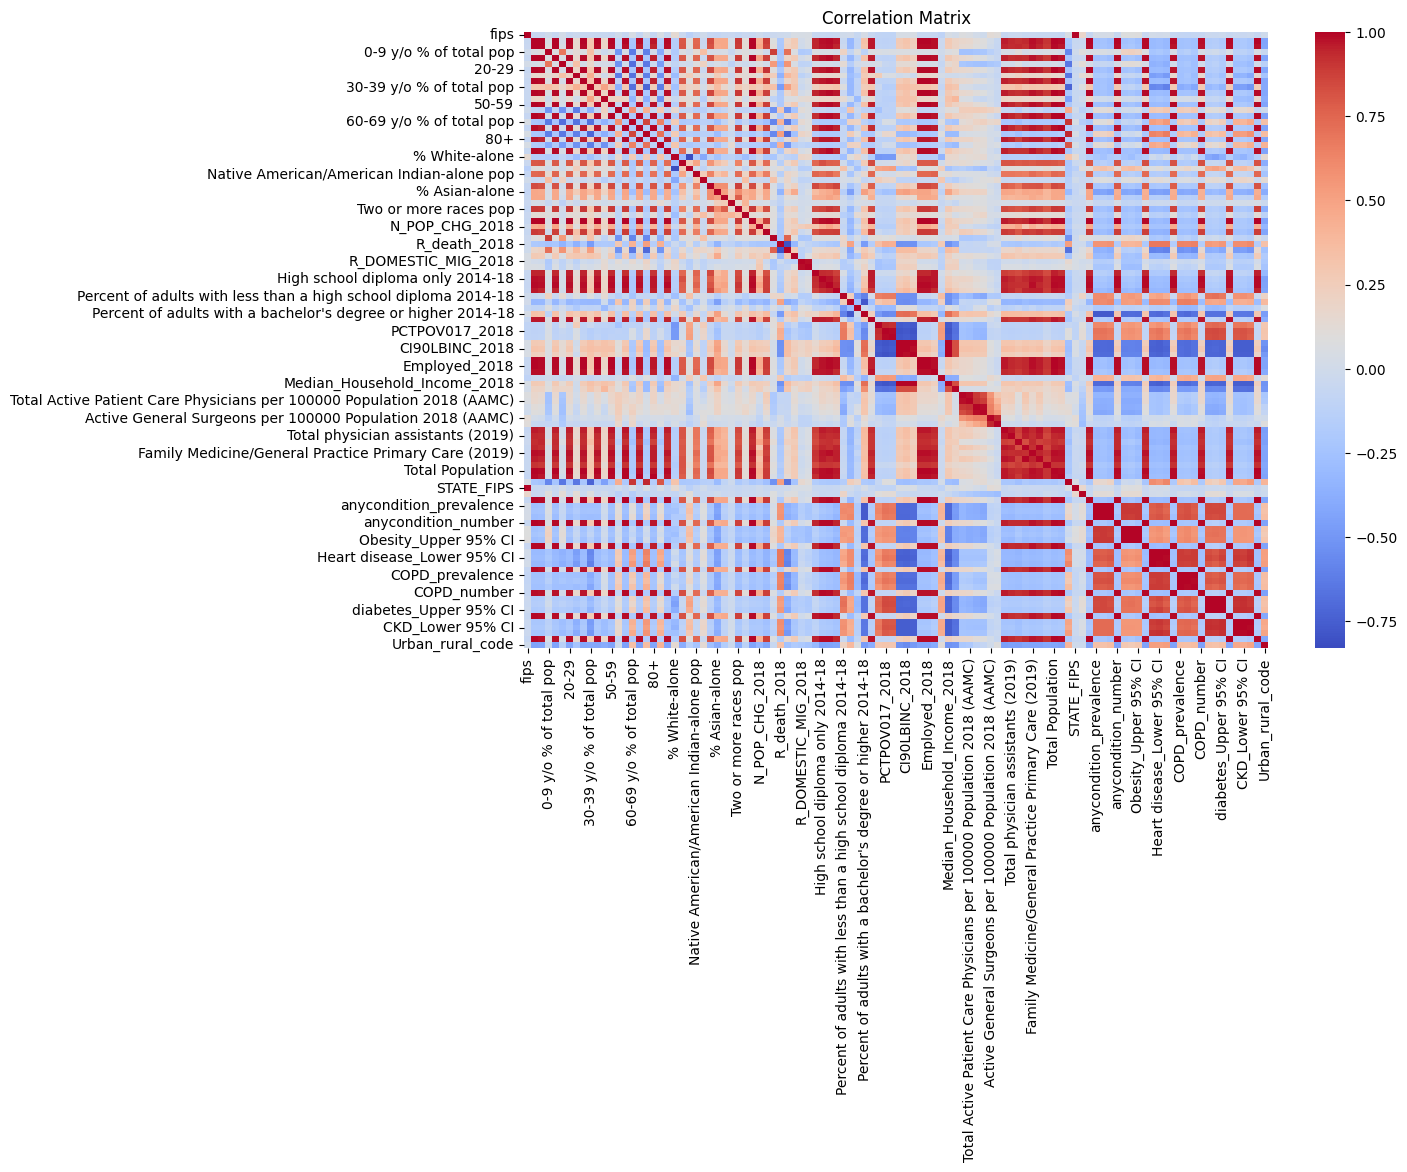

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")

plt.show()

### **Correlaciones de edades**

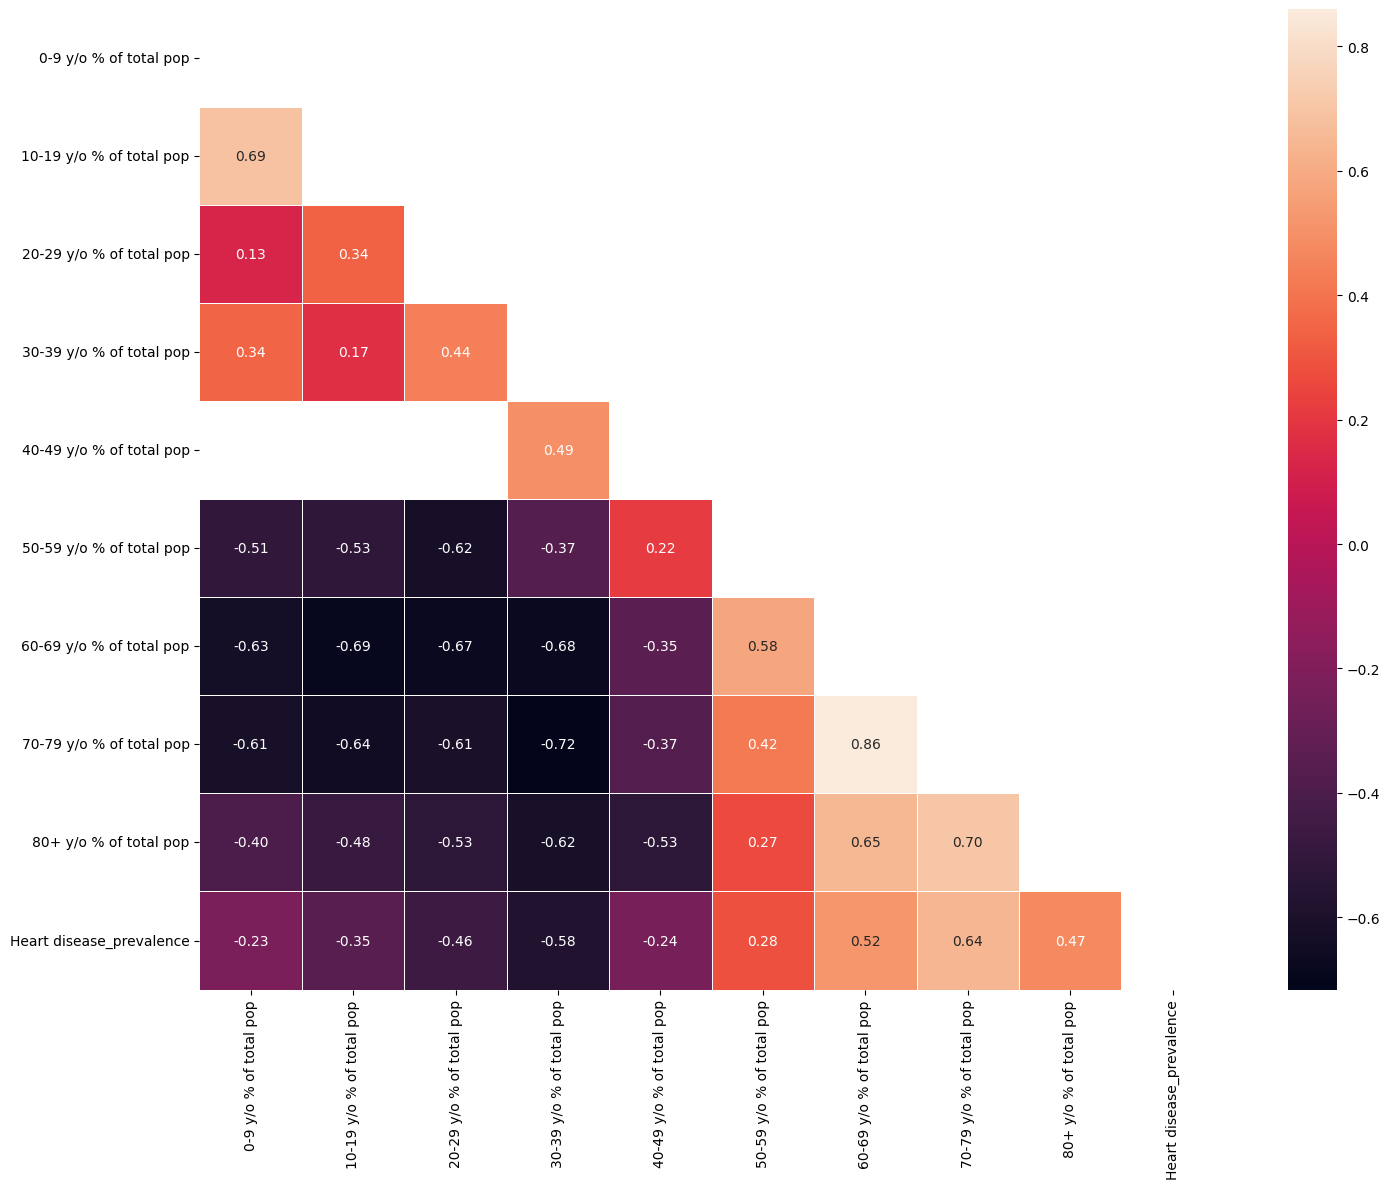

In [14]:
age_col = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", 
       "30-39 y/o % of total pop", "40-49 y/o % of total pop",
       "50-59 y/o % of total pop", "60-69 y/o % of total pop", 
       "70-79 y/o % of total pop", "80+ y/o % of total pop", 
       "Heart disease_prevalence"]

# heatmap
corr = df[age_col].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()




In [15]:
# Combine age groups into broader categories 
df["age 0-19 pct %"] = df["0-9 y/o % of total pop"] + df["10-19 y/o % of total pop"]
df["age 20-39 pct %"] = df["20-29 y/o % of total pop"] + df["30-39 y/o % of total pop"]
df["age 40-59 pct %"] = df["40-49 y/o % of total pop"] + df["50-59 y/o % of total pop"]
df["age 60-79 pct %"] = df["60-69 y/o % of total pop"] + df["70-79 y/o % of total pop"]
df["age 80+ pct %"] = df["80+ y/o % of total pop"]



/tmp/ipykernel_5413/3308689083.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age 0-19 pct %"] = df["0-9 y/o % of total pop"] + df["10-19 y/o % of total pop"]
/tmp/ipykernel_5413/3308689083.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age 20-39 pct %"] = df["20-29 y/o % of total pop"] + df["30-39 y/o % of total pop"]
/tmp/ipykernel_5413/3308689083.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

In [16]:
age_columns_to_drop = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", "30-39 y/o % of total pop", "40-49 y/o % of total pop",
                       "50-59 y/o % of total pop", "60-69 y/o % of total pop", "70-79 y/o % of total pop", "80+ y/o % of total pop"]

df = df.drop(age_columns_to_drop, axis = 1)

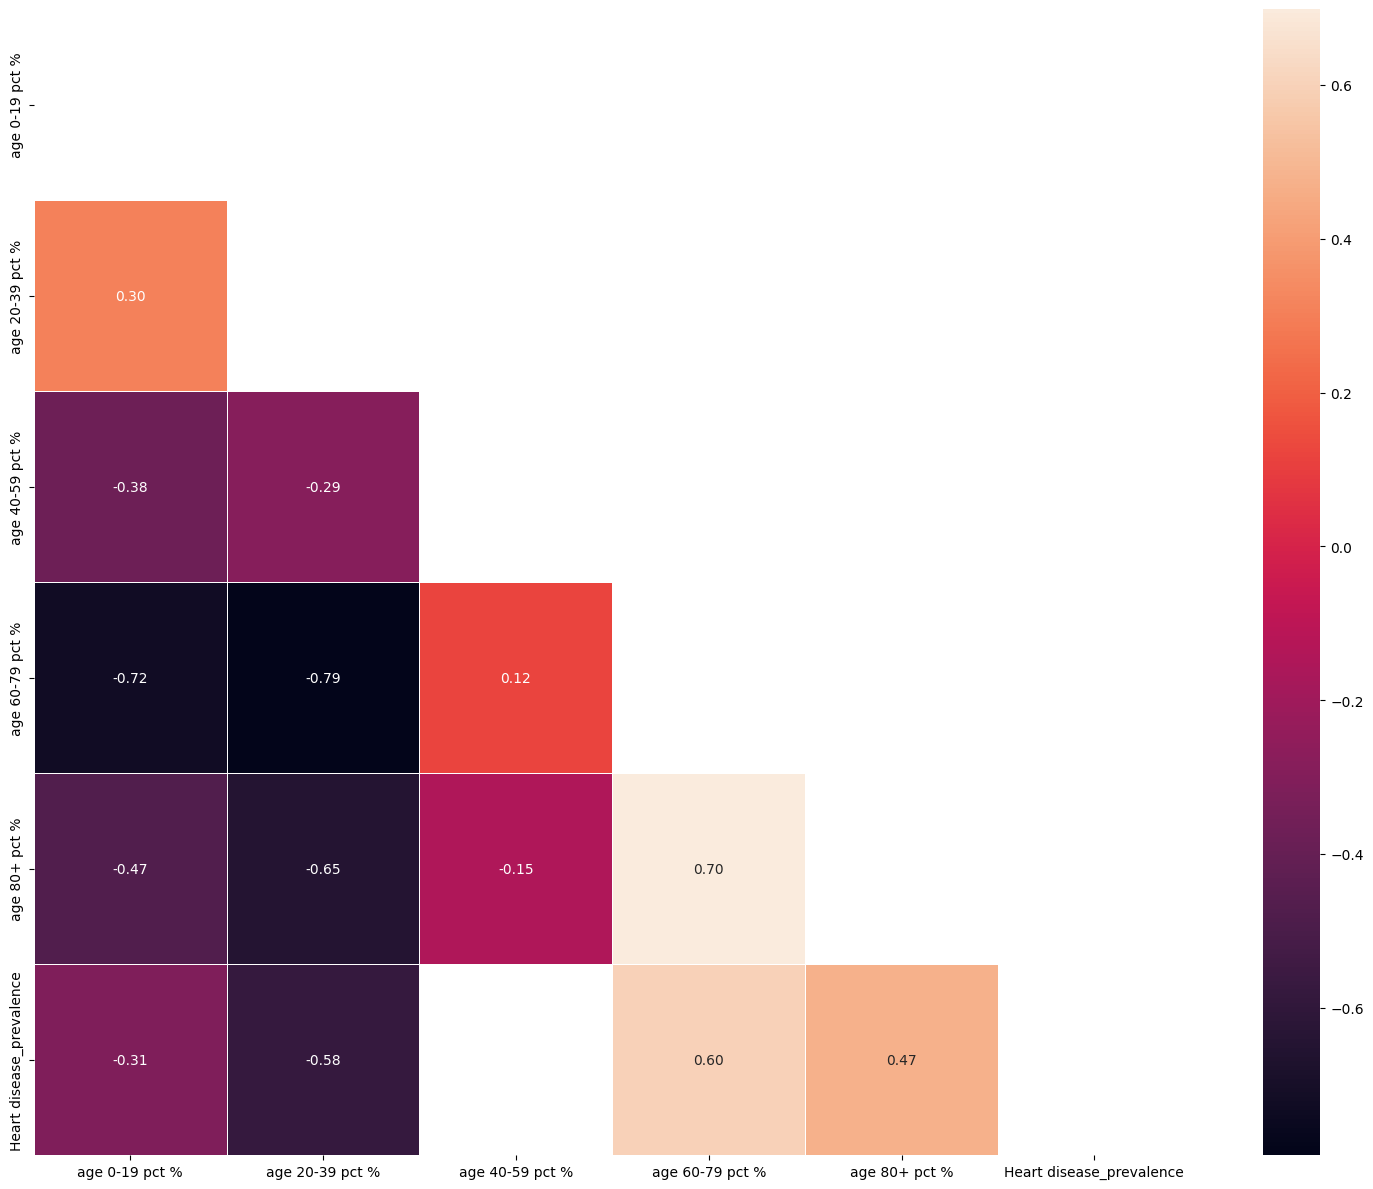

In [17]:
age_col_two = ["age 0-19 pct %", "age 20-39 pct %", "age 40-59 pct %", "age 60-79 pct %", "age 80+ pct %", "Heart disease_prevalence"]
# heatmap
corr = df[age_col_two].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

### **Segundo heatmap de comparación con las columnas finales elegidas**:

In [18]:

others_filtered = ['Percent of Population Aged 60+',
       'county_pop2018_18 and older', 'anycondition_prevalence',
       'Obesity_prevalence', 'COPD_prevalence',
       'diabetes_prevalence', 
       'CKD_prevalence', 'age 0-19 pct %',
       'age 20-39 pct %', 'age 40-59 pct %', 'age 60-79 pct %',
       'age 80+ pct %', 'Heart disease_prevalence']

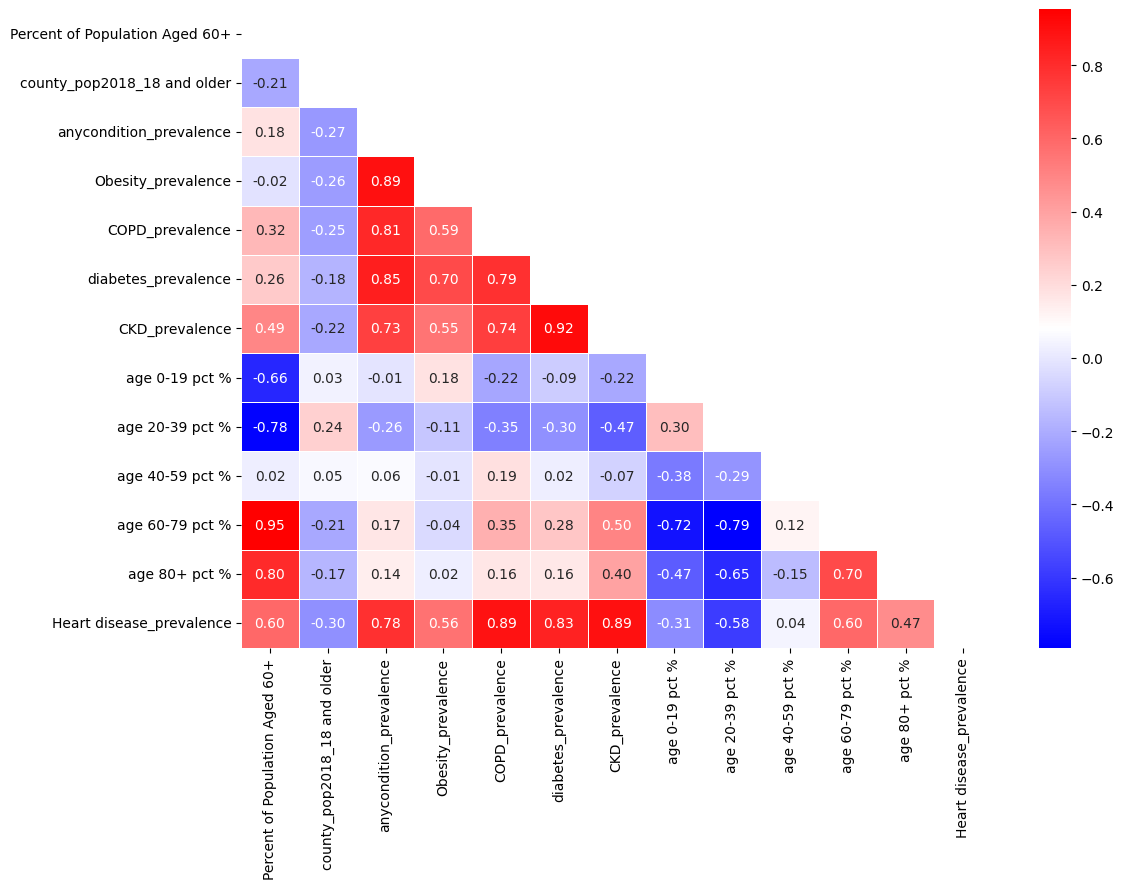

In [19]:
corr = df[others_filtered].corr

corr = df[others_filtered].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='bwr')

plt.tight_layout()
plt.show()

**Drops**:

In [20]:
df = df.drop(["county_pop2018_18 and older", "anycondition_prevalence", "Percent of Population Aged 60+"], axis=1)

### **Columnas para el analisis:**

**Observaciones y drops finales**:
> * Country_pop2018 se elimina porque ya tenemos una columna que se refiere a ese rango de edad ----> 
> * Me quedo con 46 columnas y todas las filas

### OUTLIERS

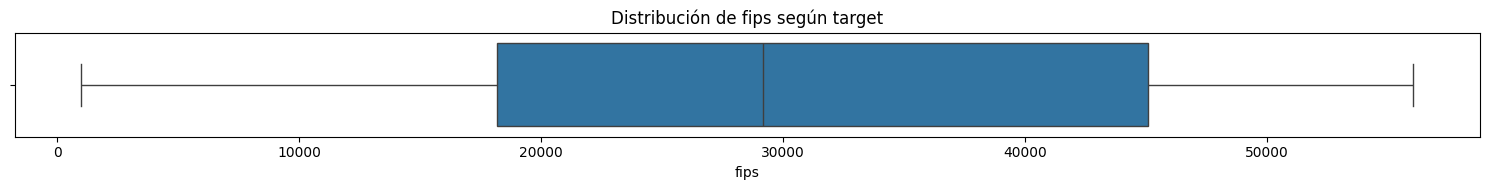

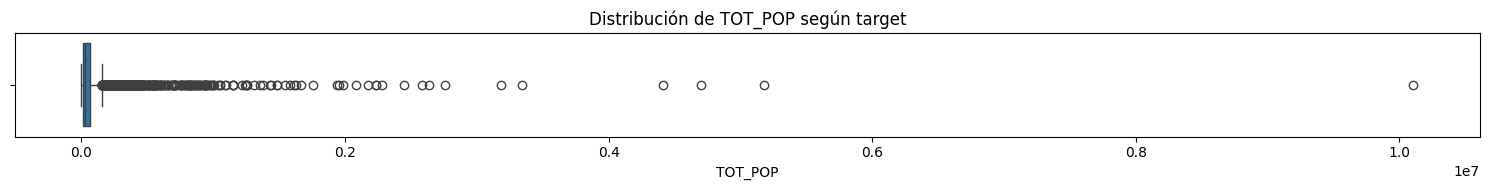

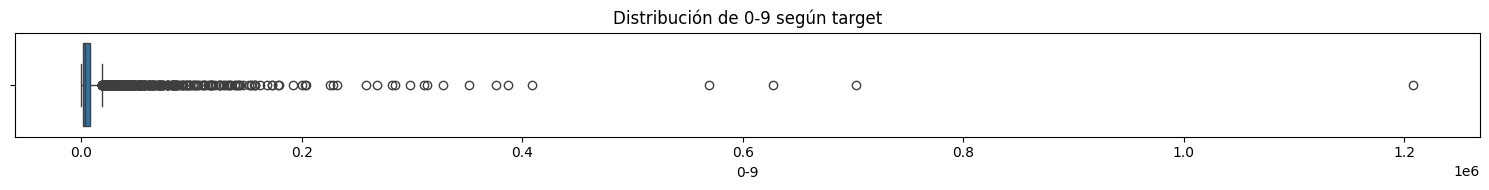

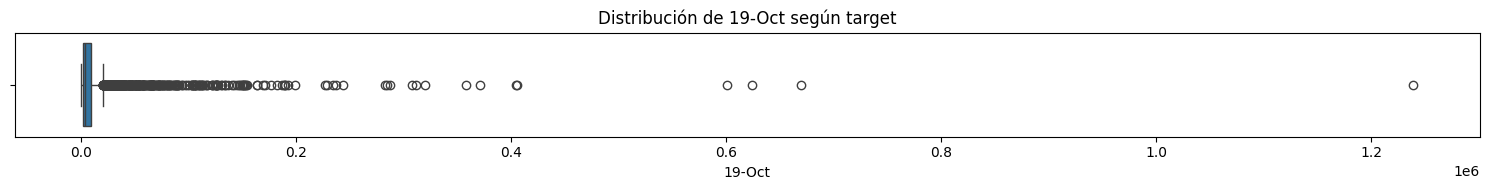

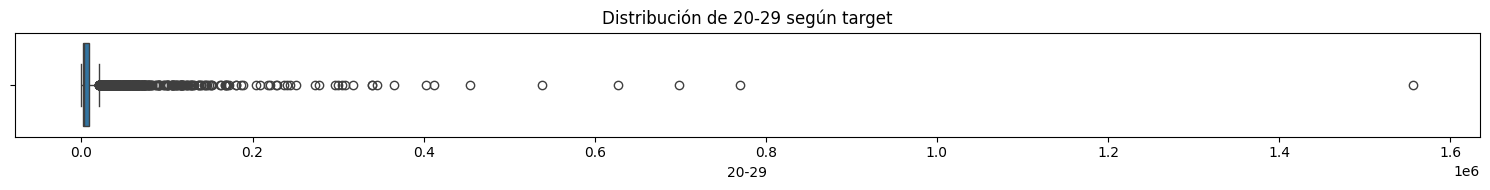

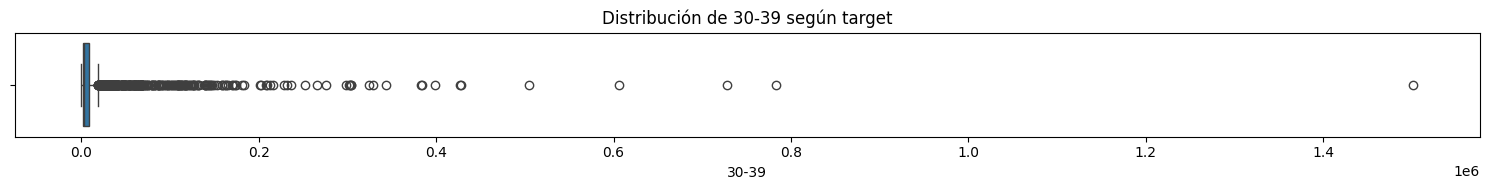

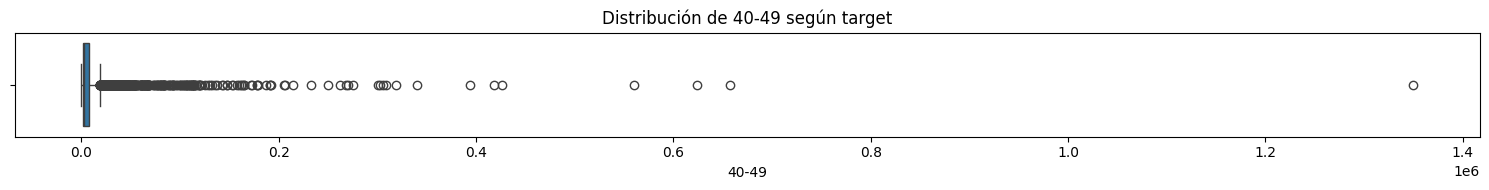

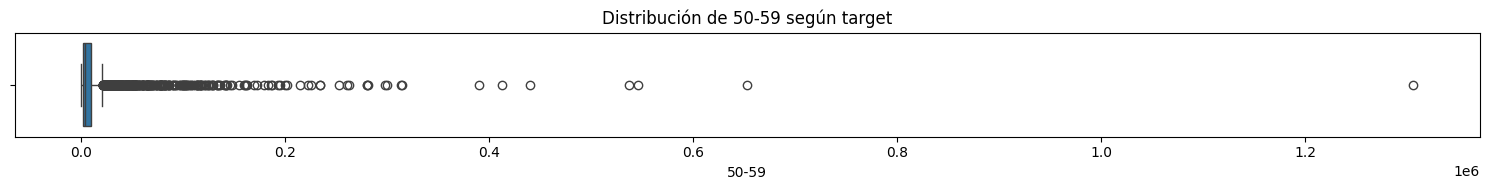

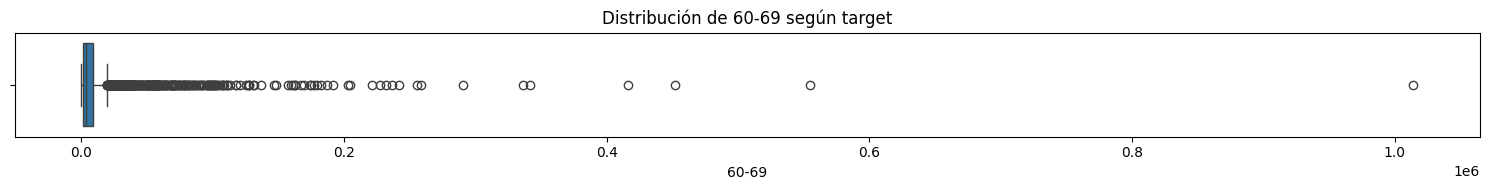

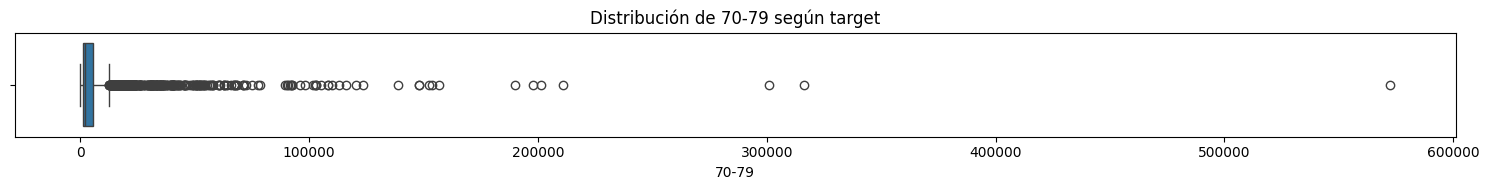

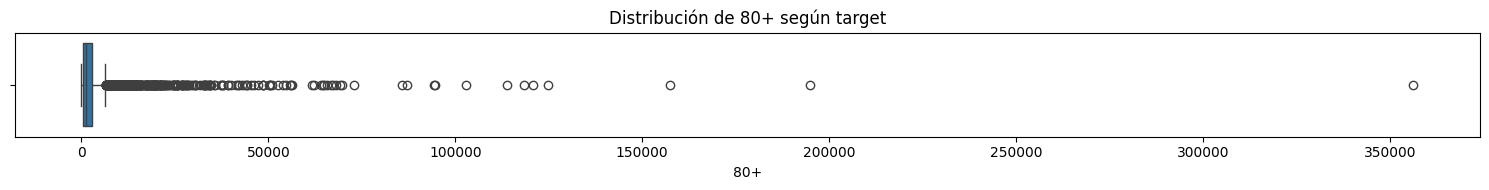

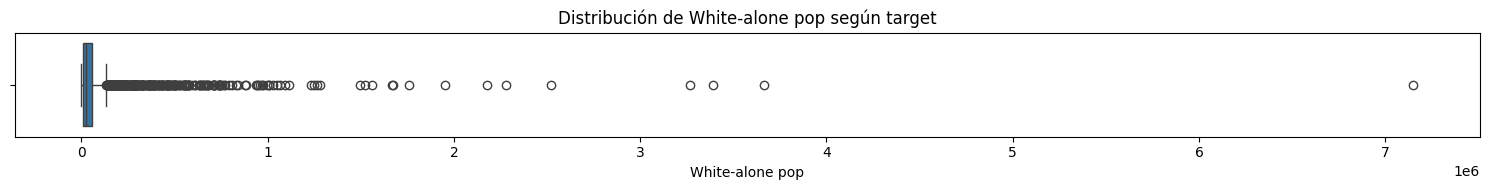

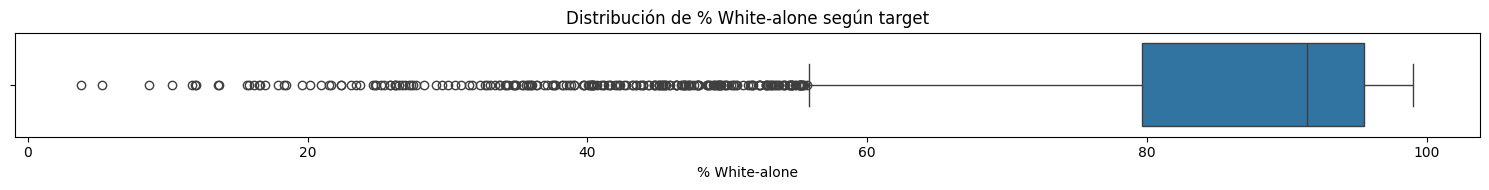

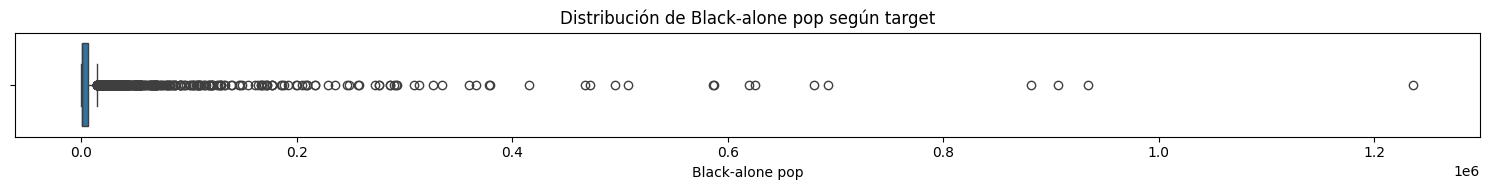

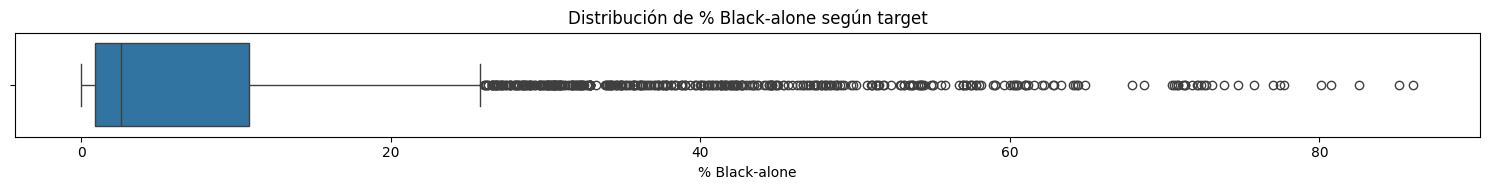

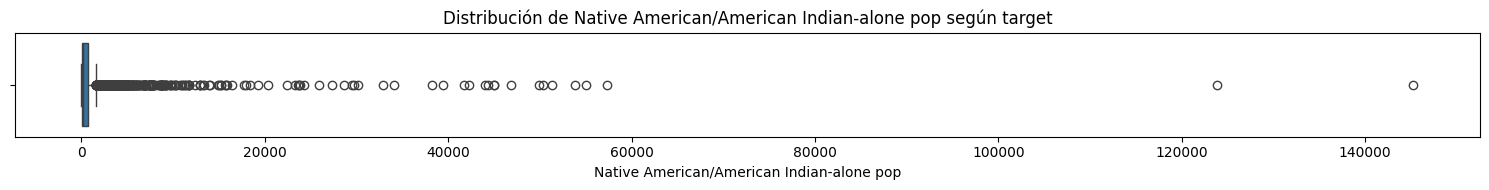

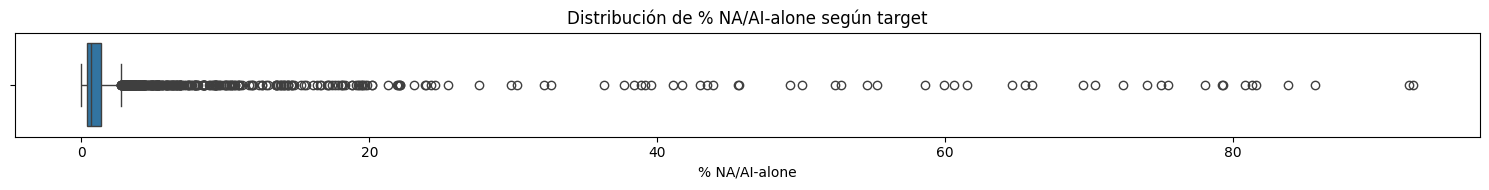

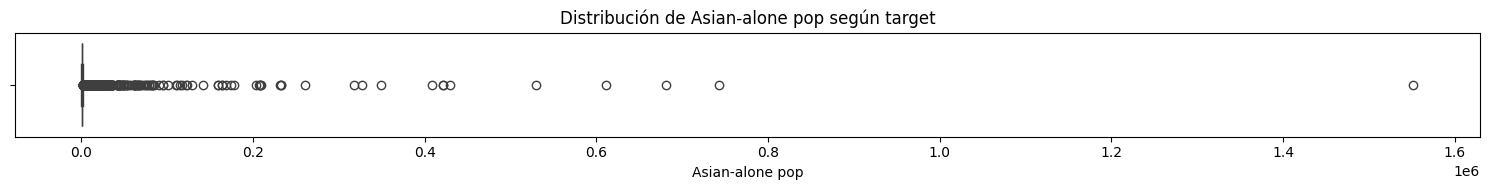

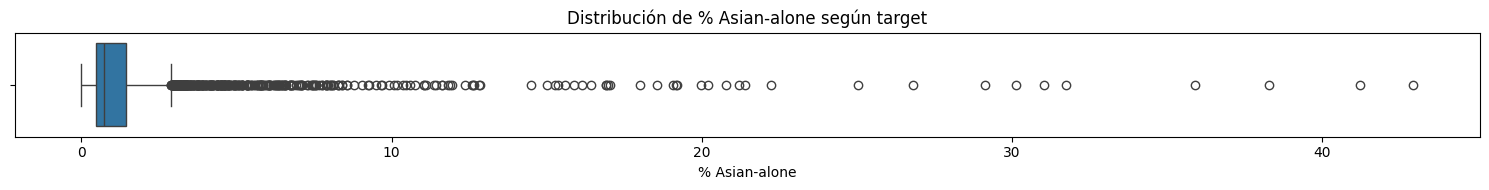

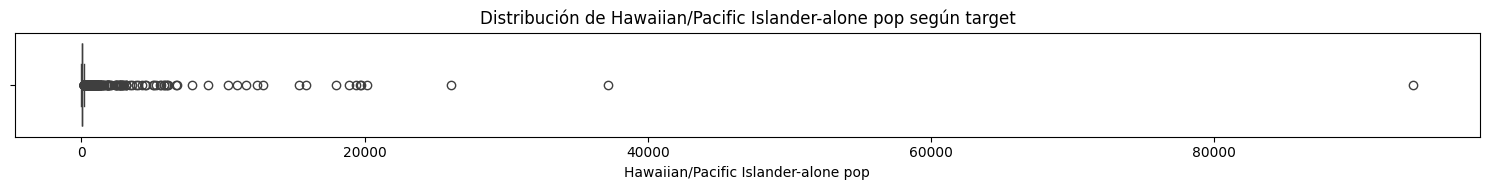

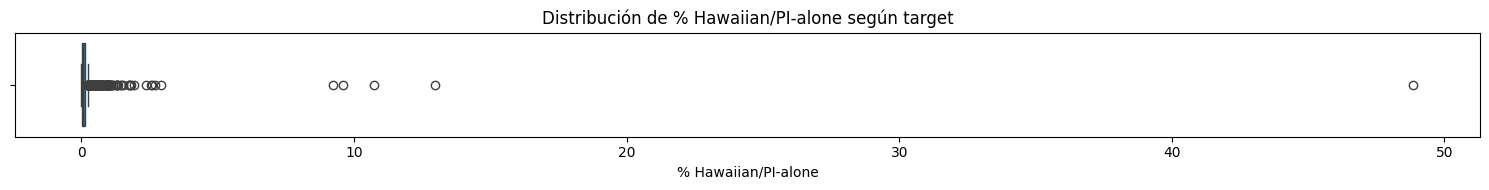

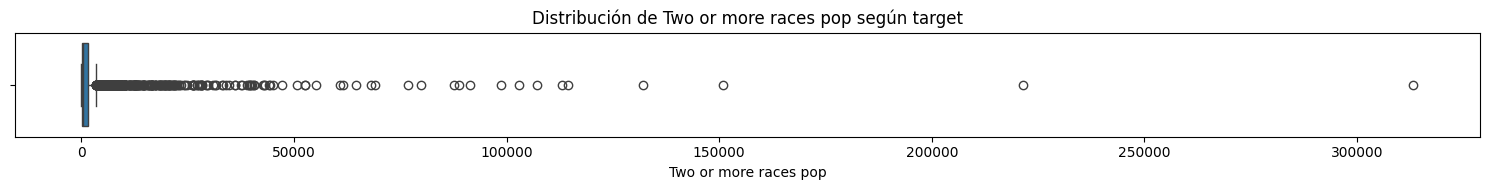

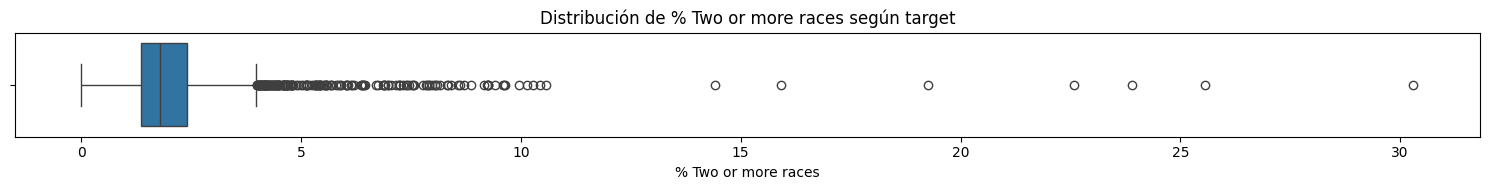

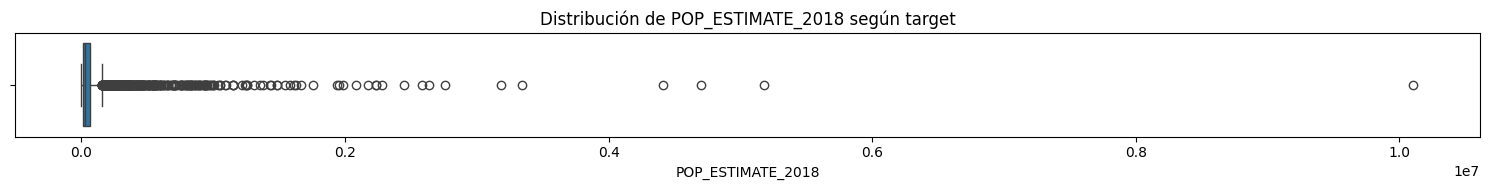

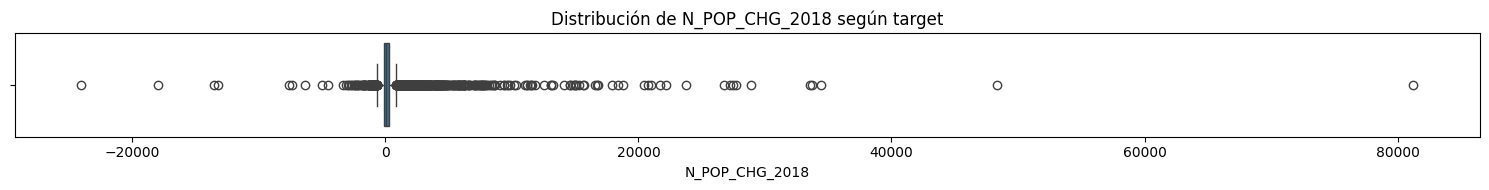

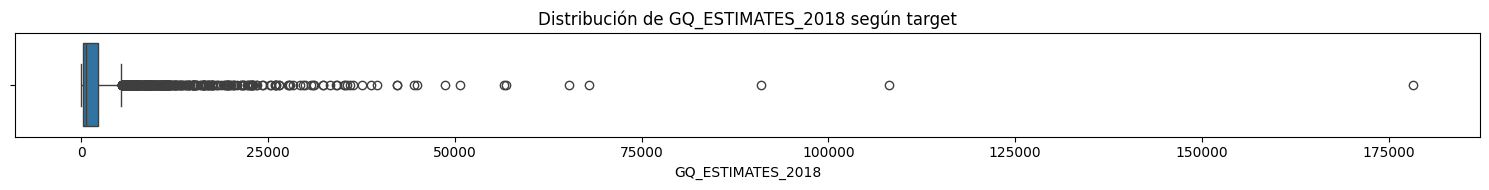

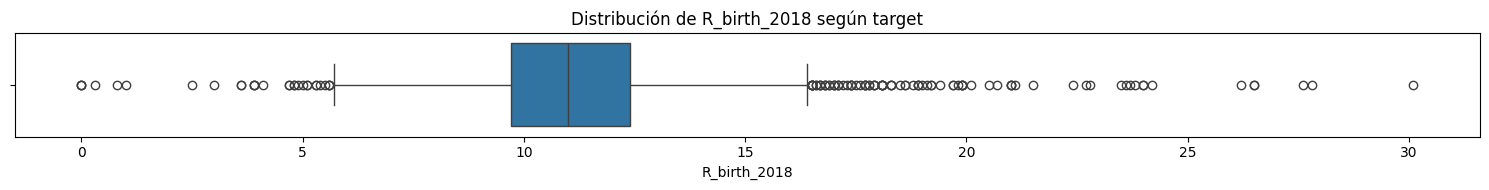

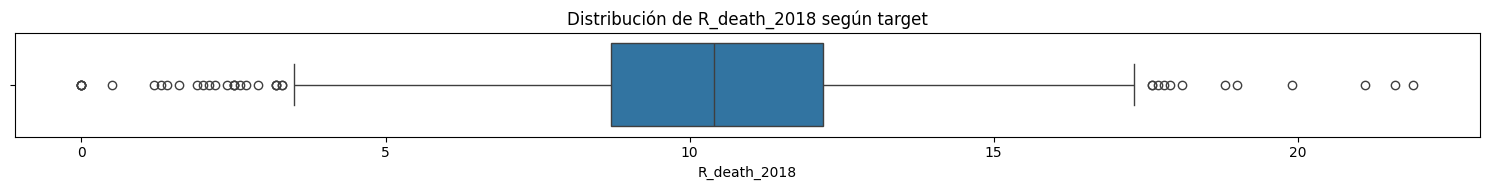

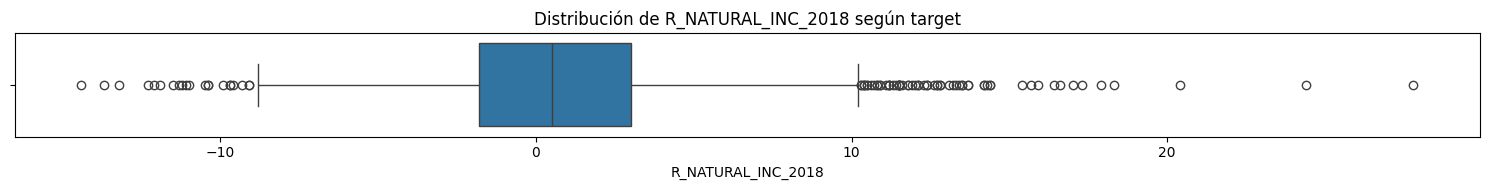

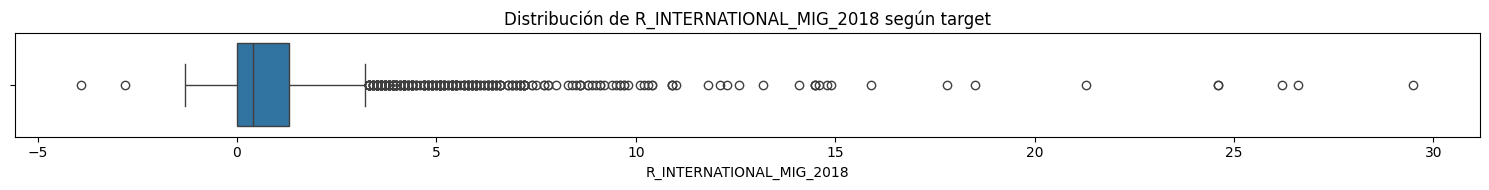

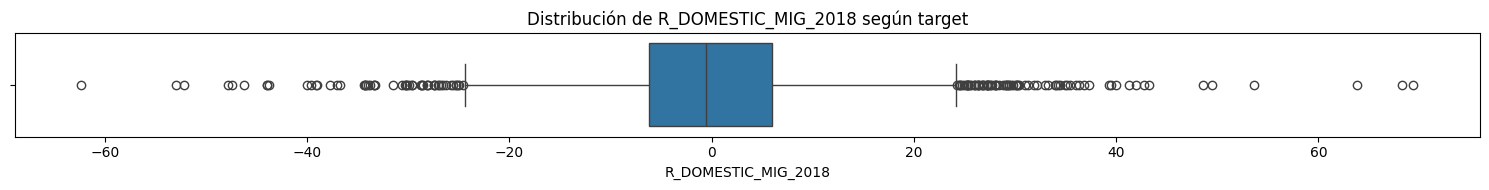

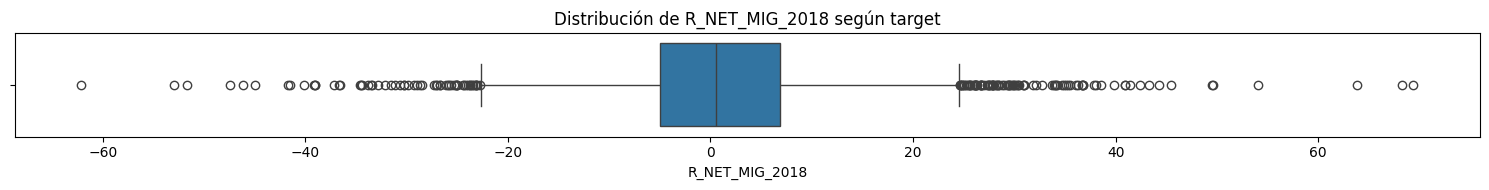

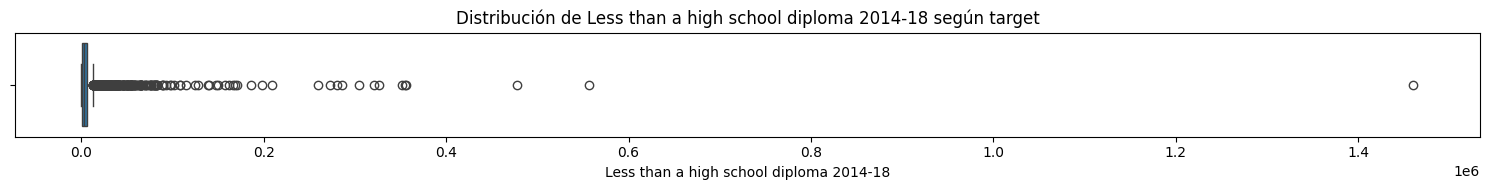

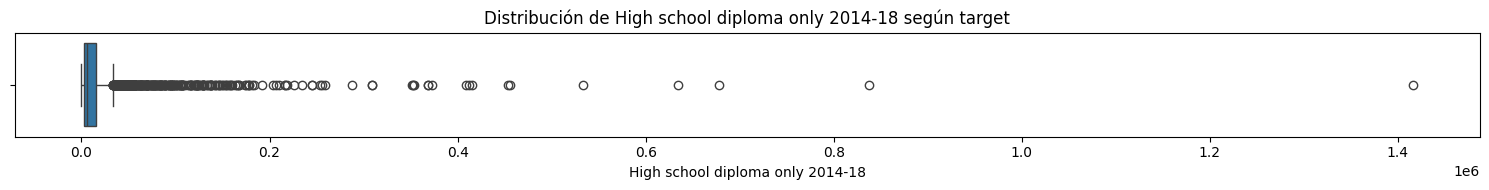

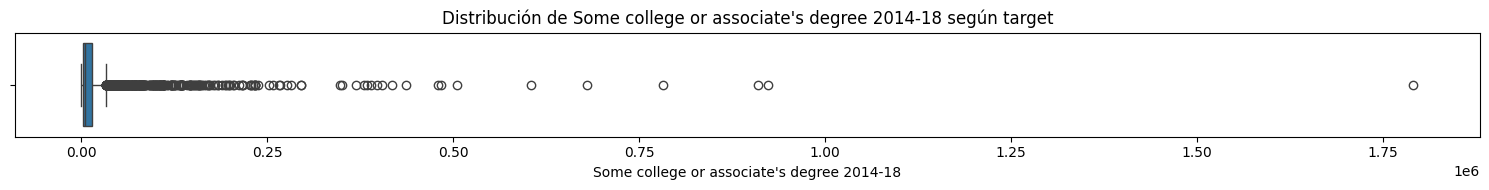

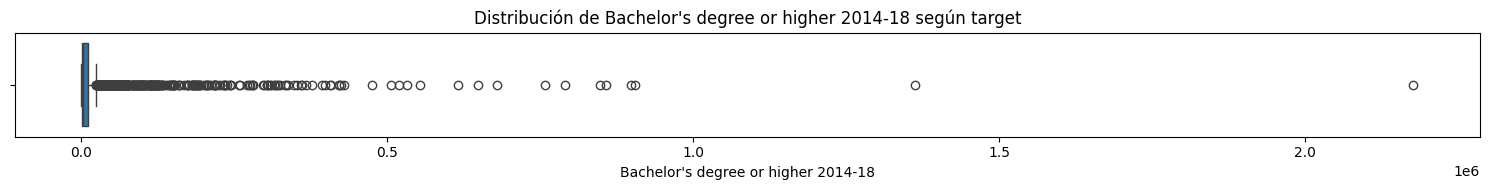

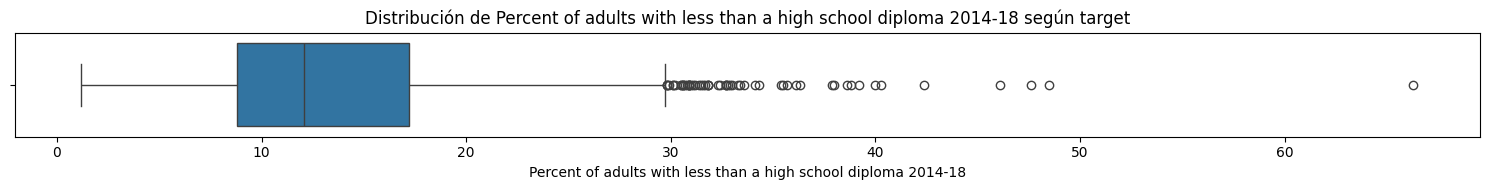

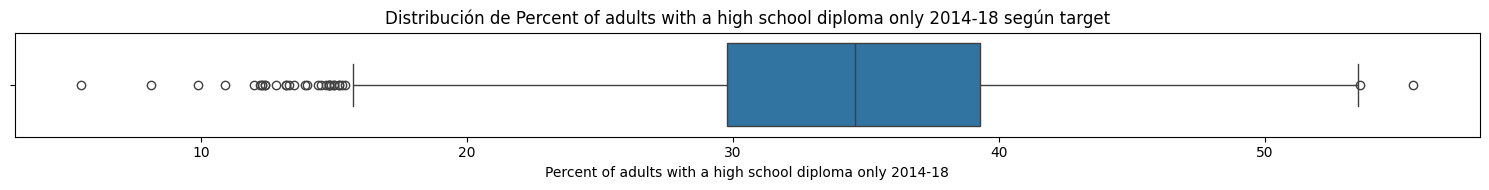

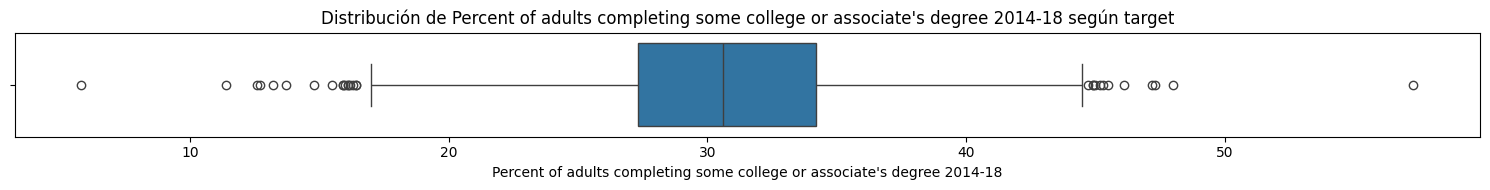

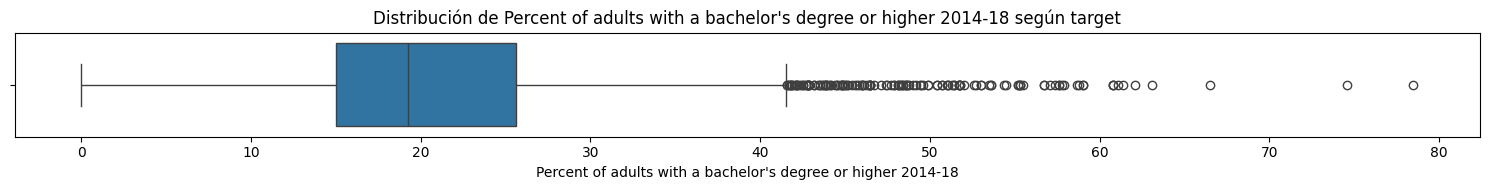

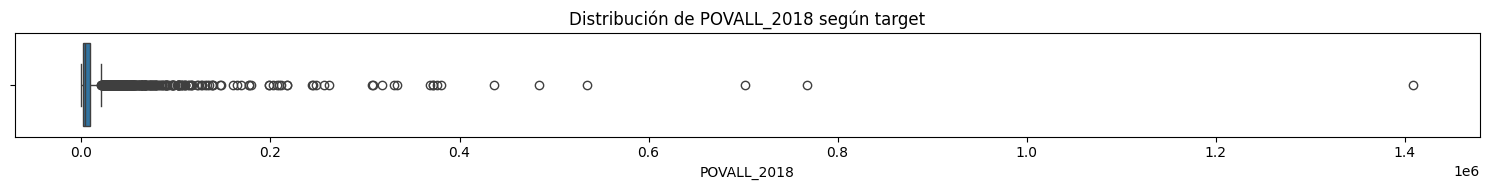

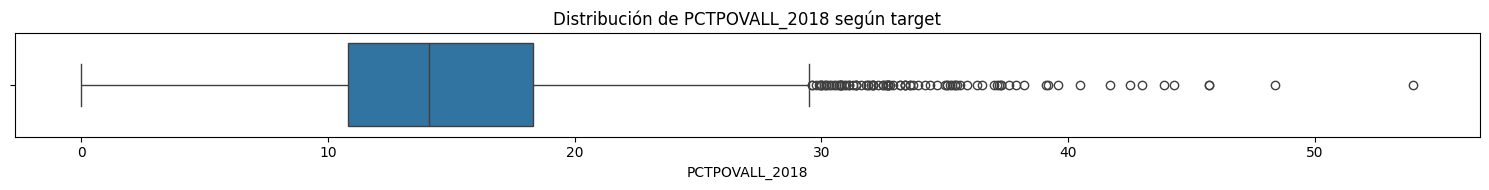

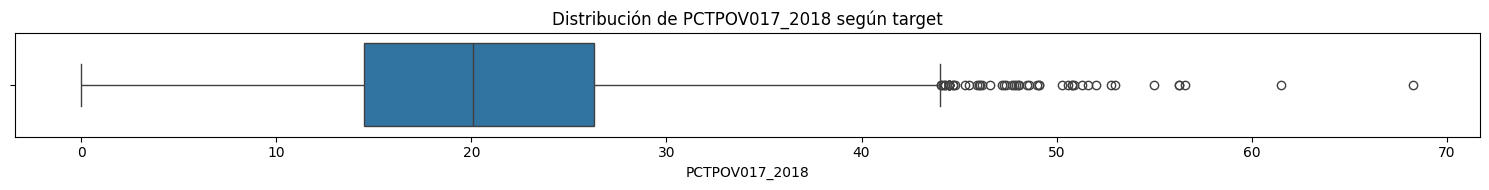

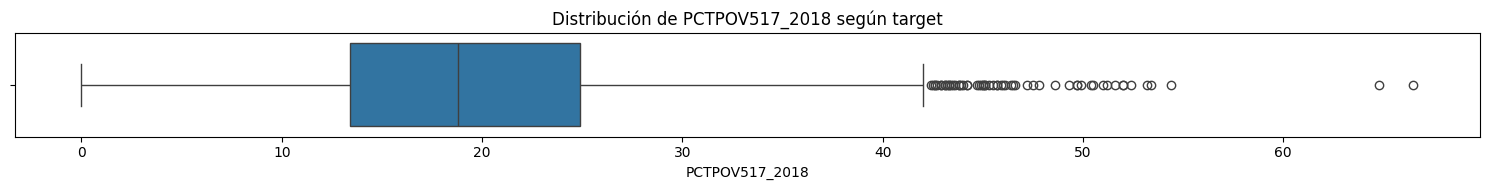

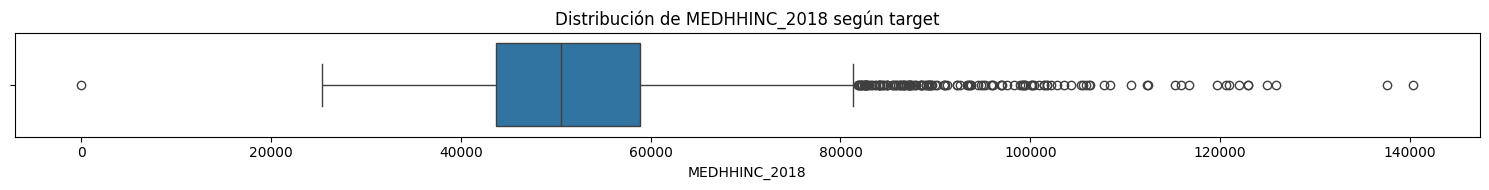

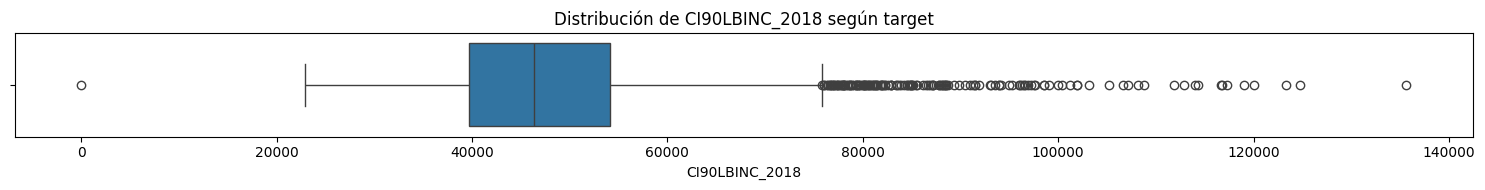

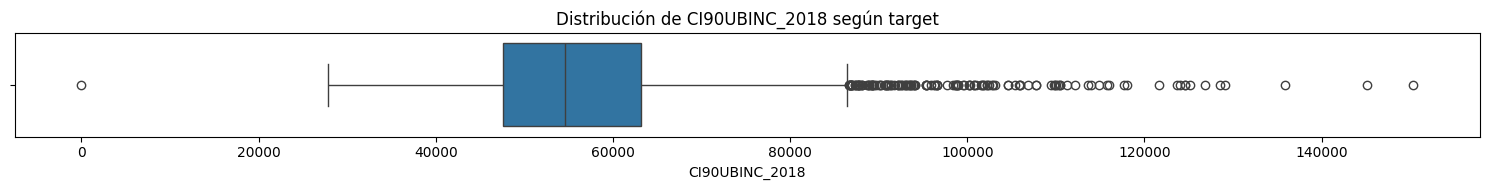

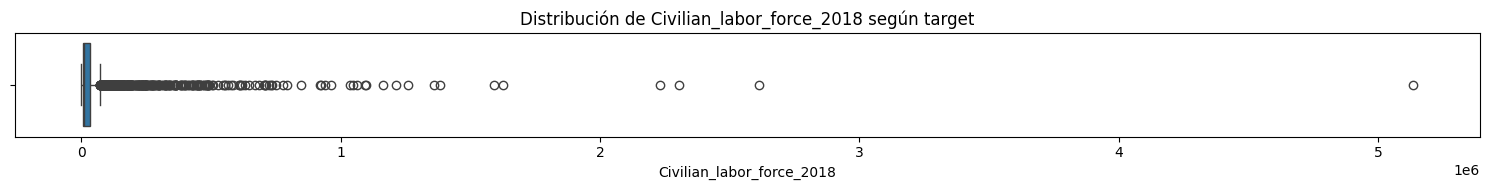

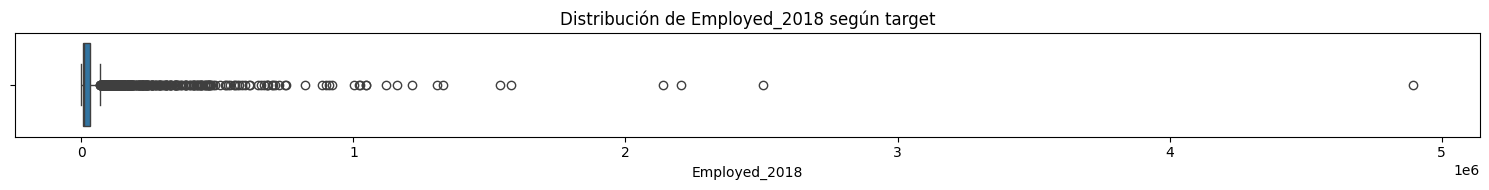

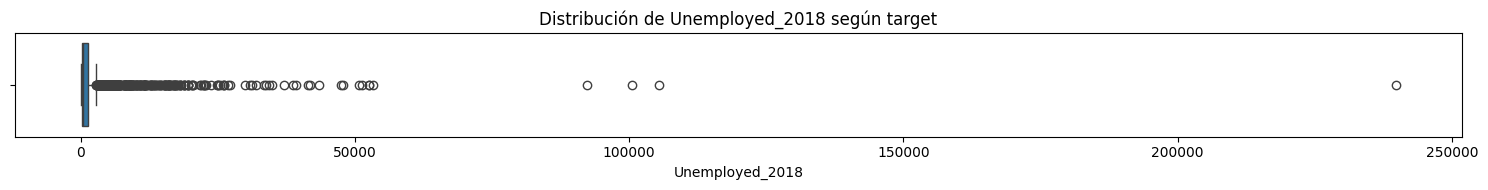

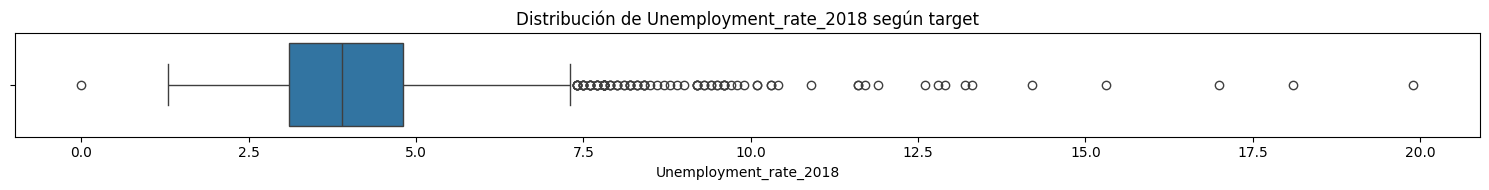

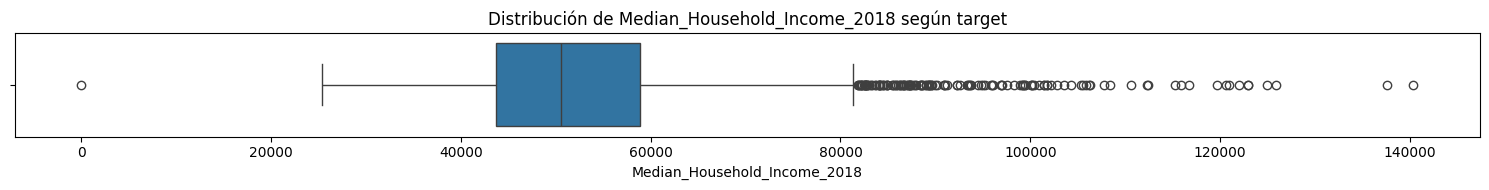

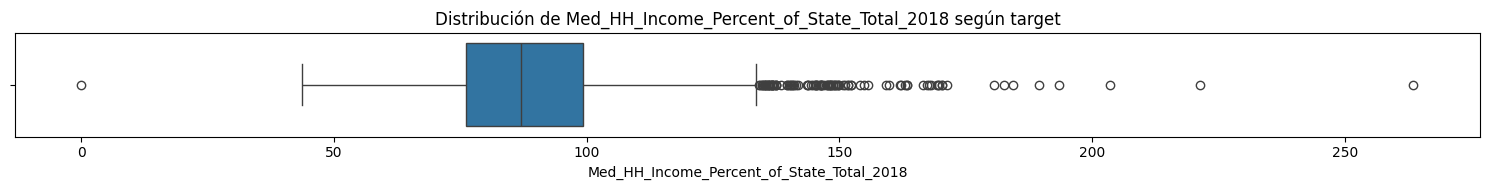

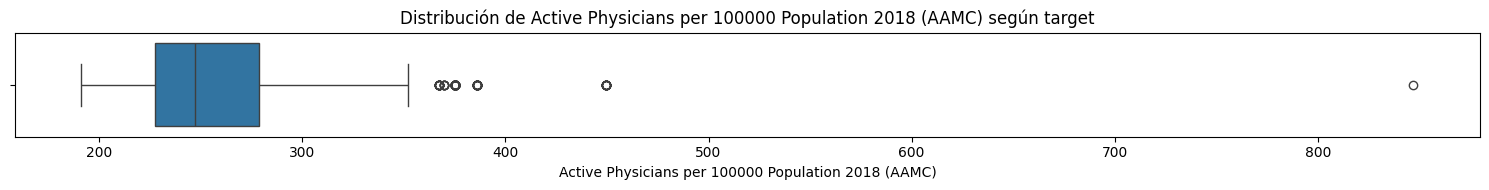

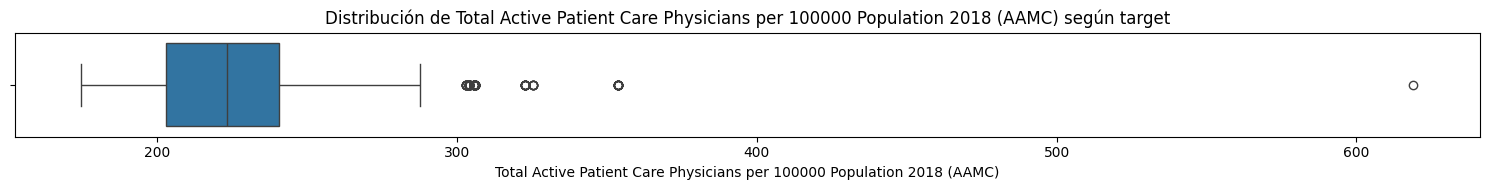

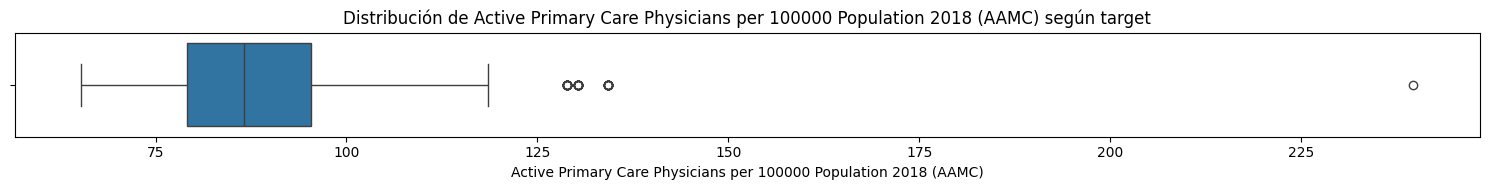

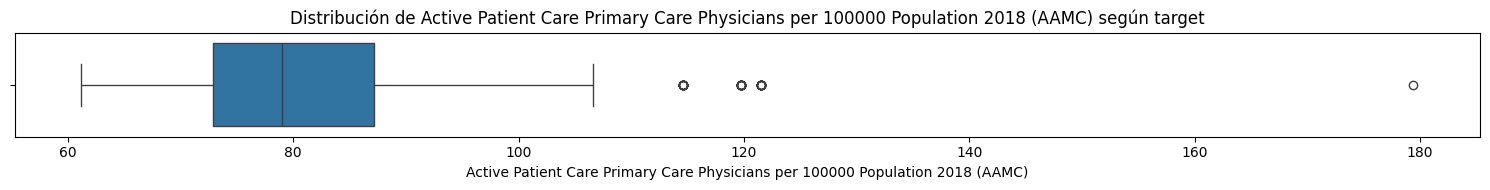

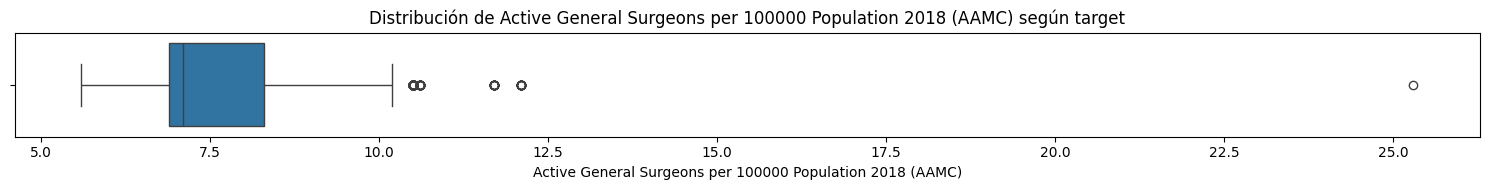

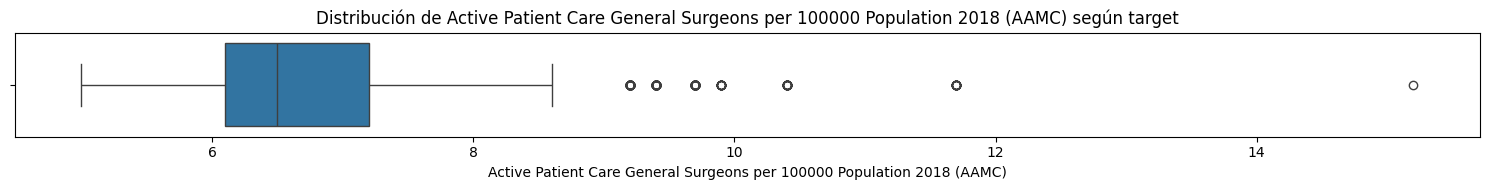

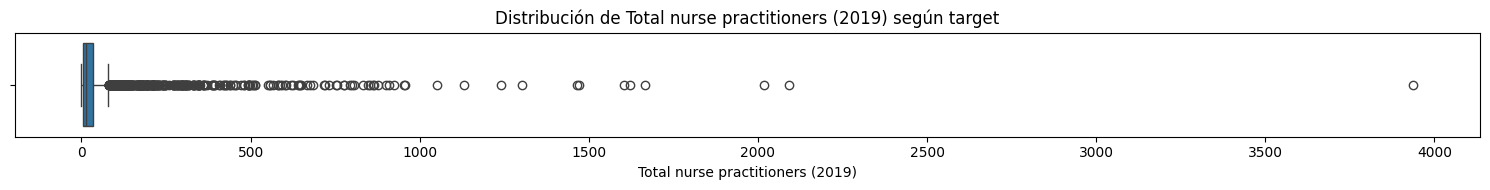

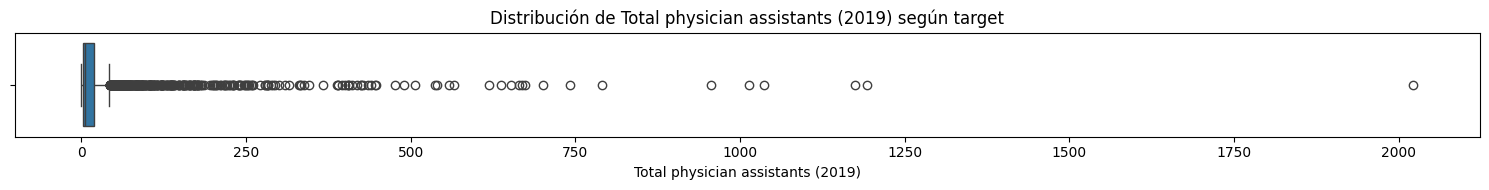

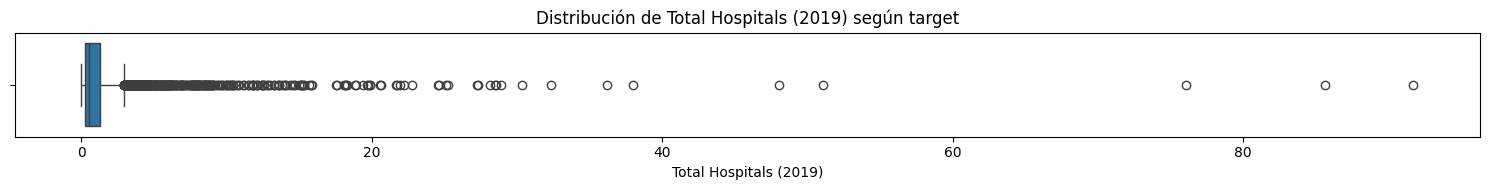

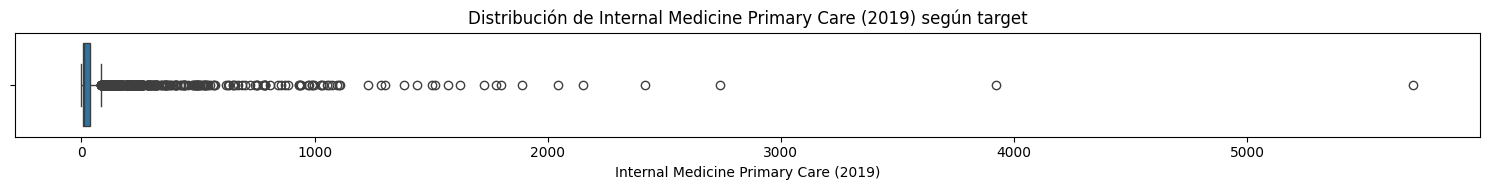

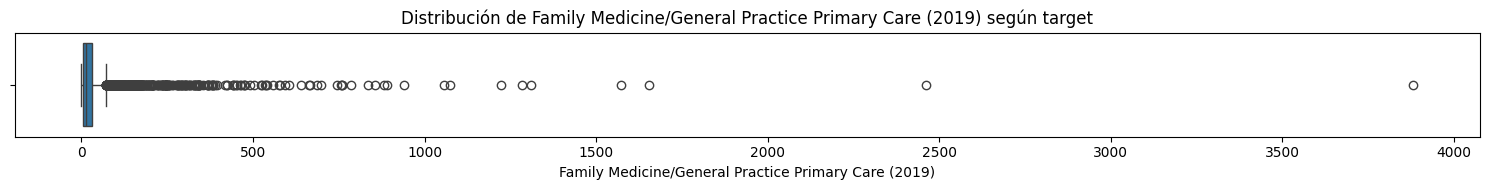

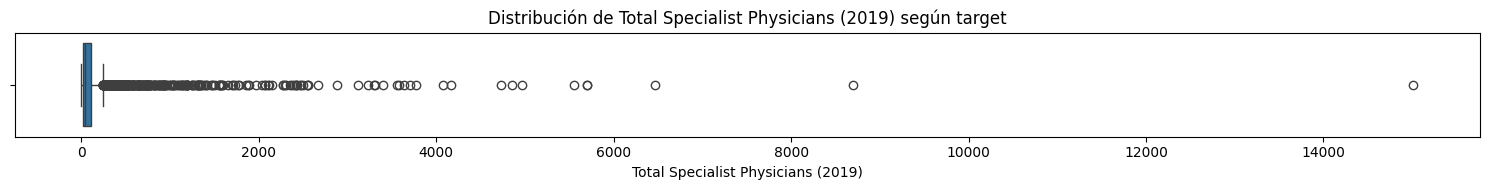

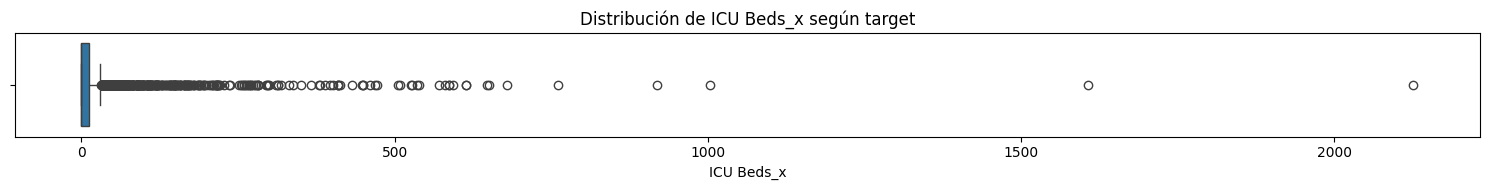

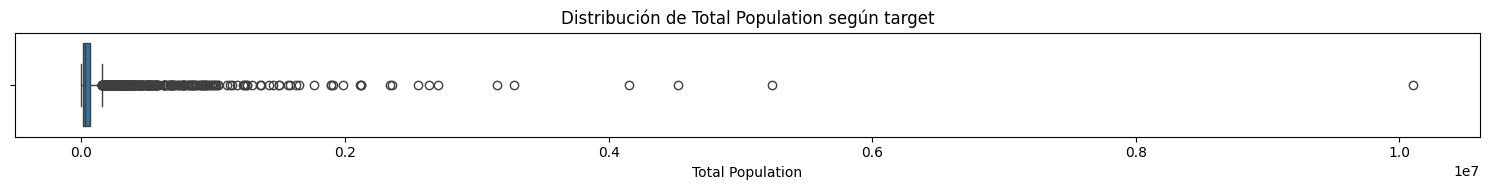

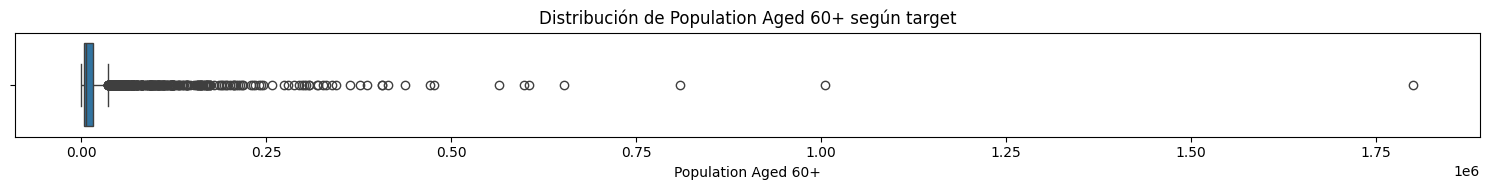

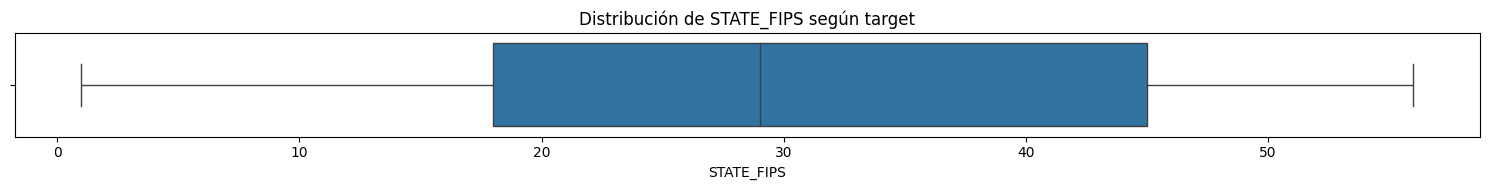

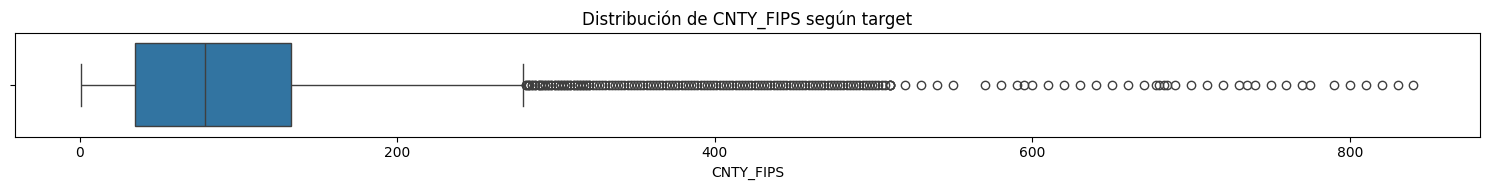

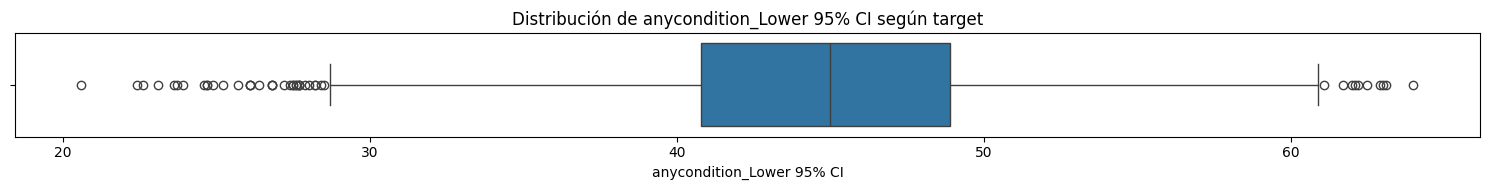

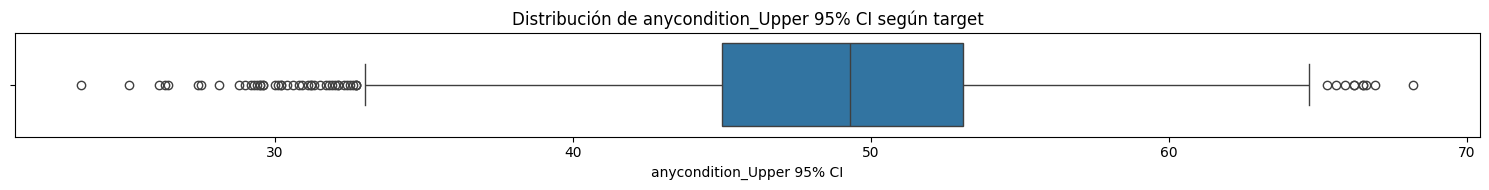

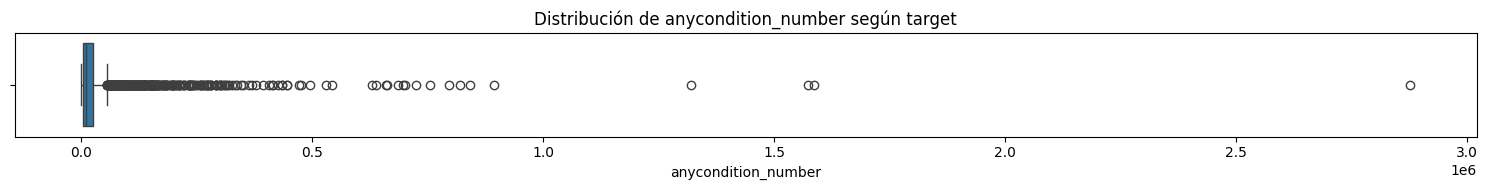

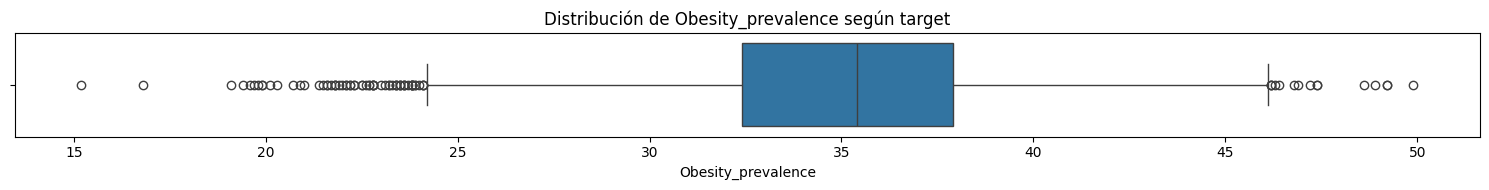

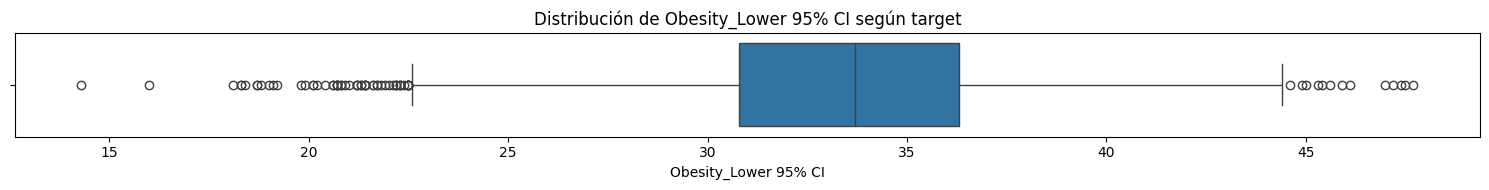

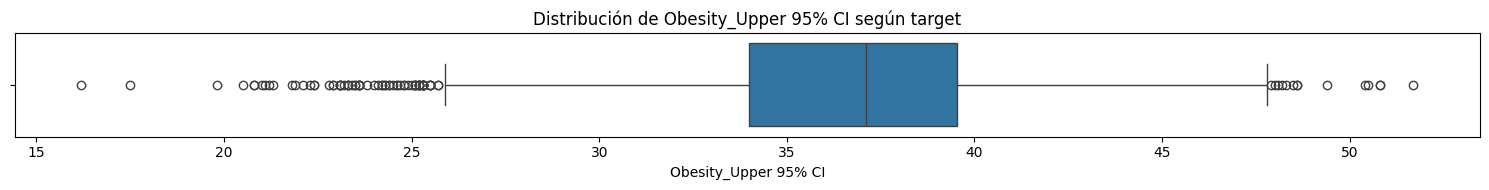

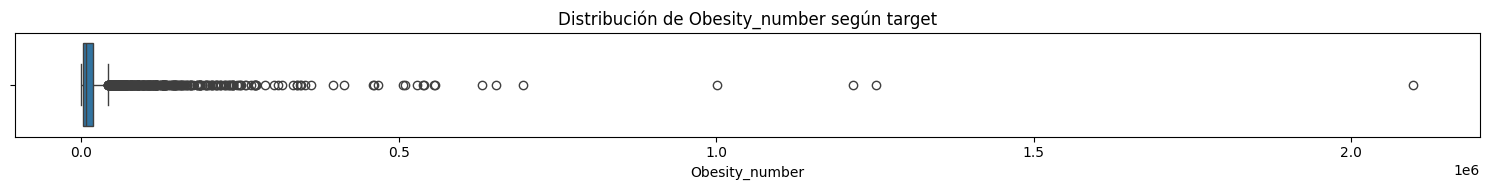

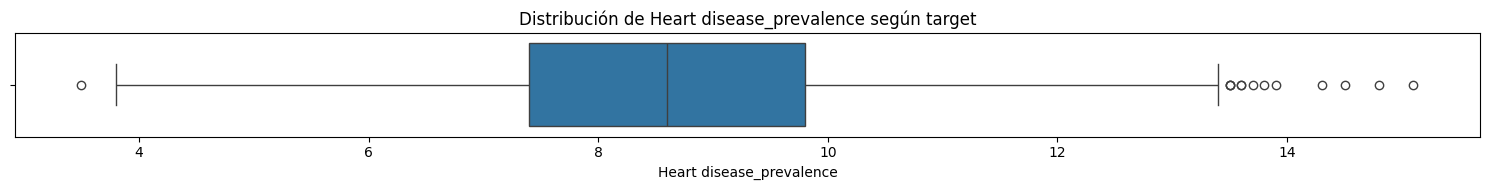

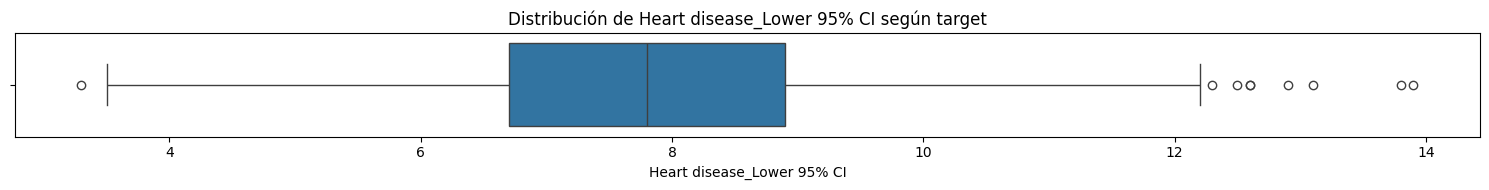

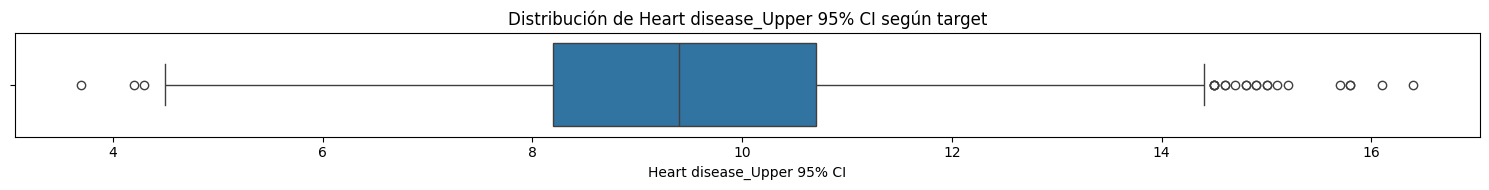

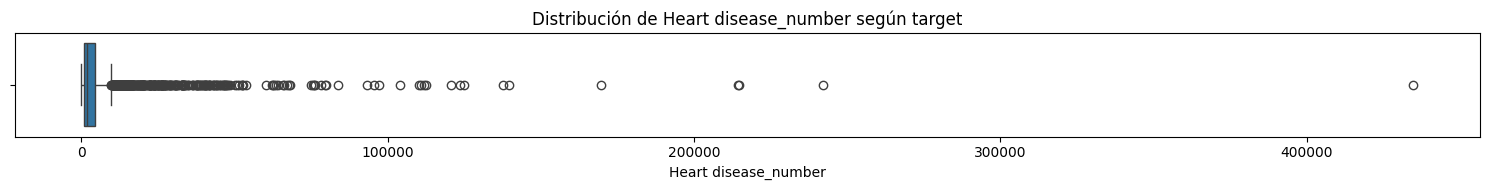

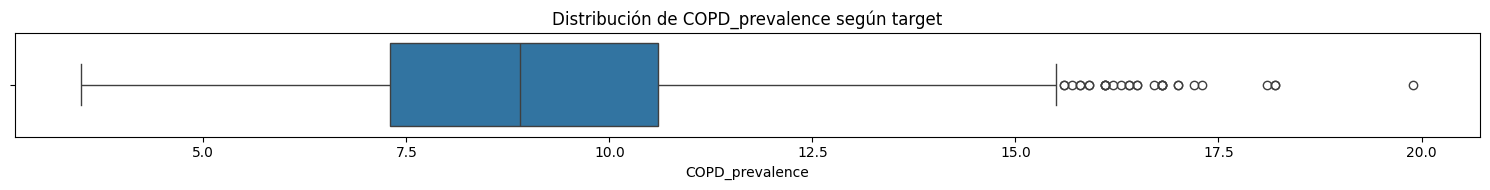

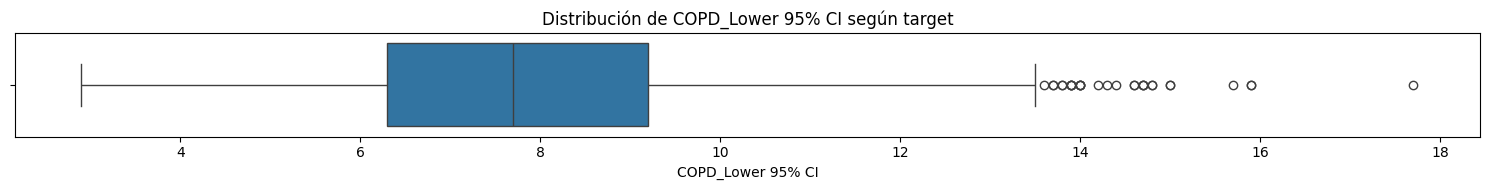

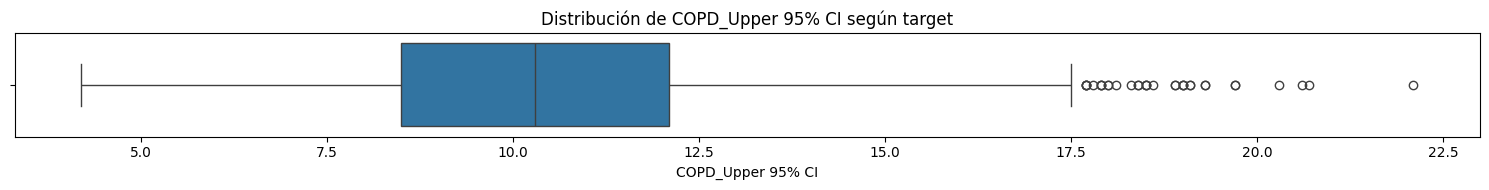

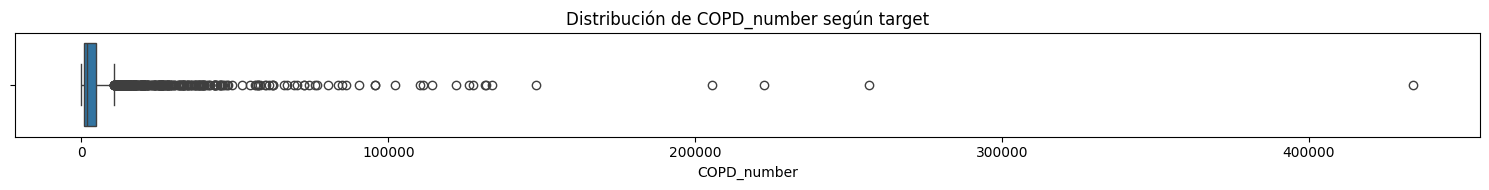

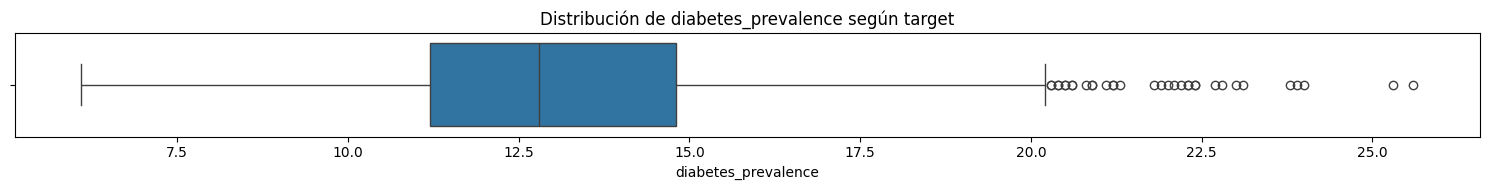

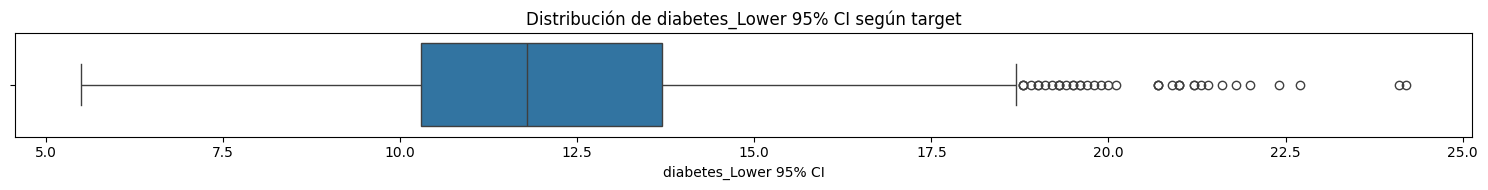

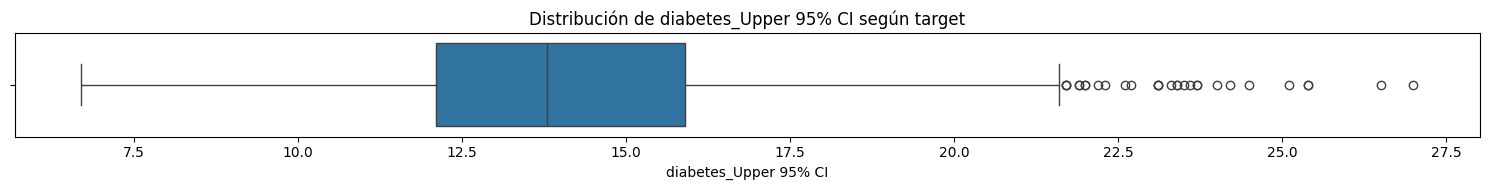

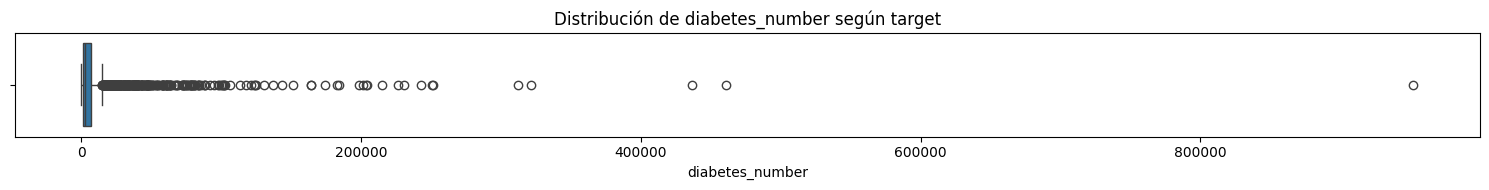

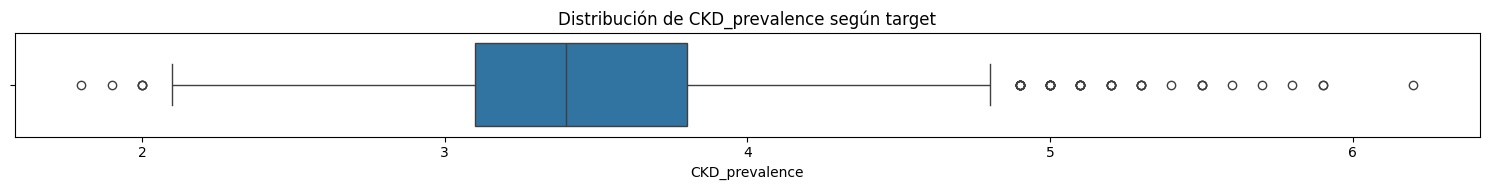

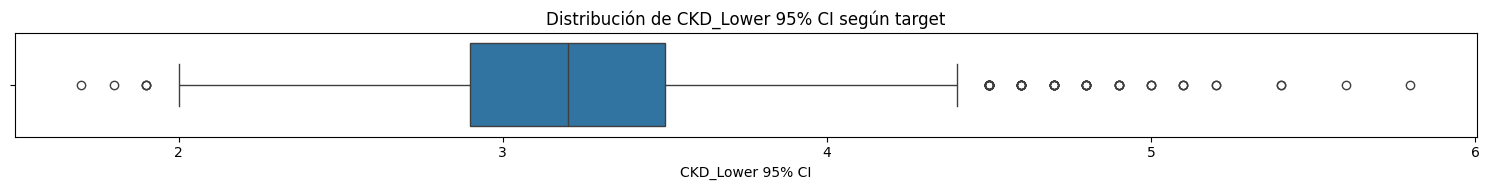

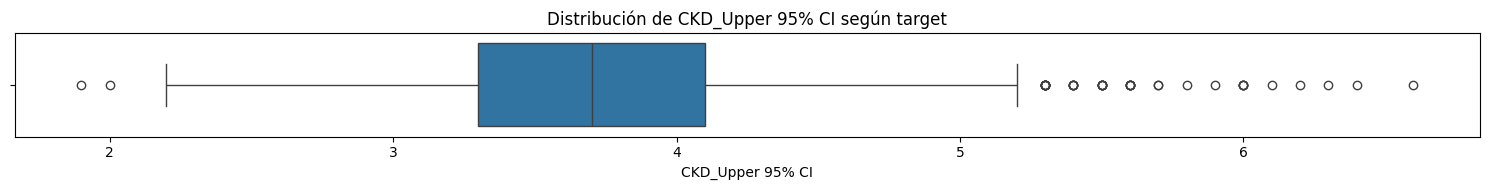

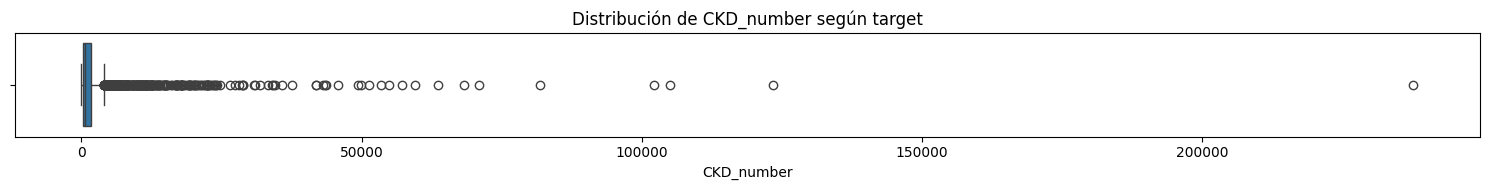

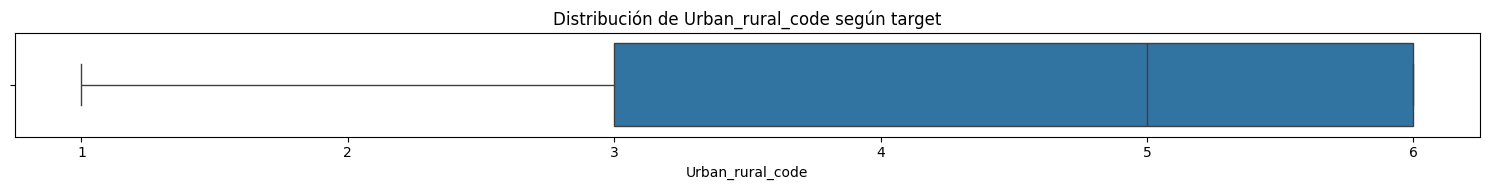

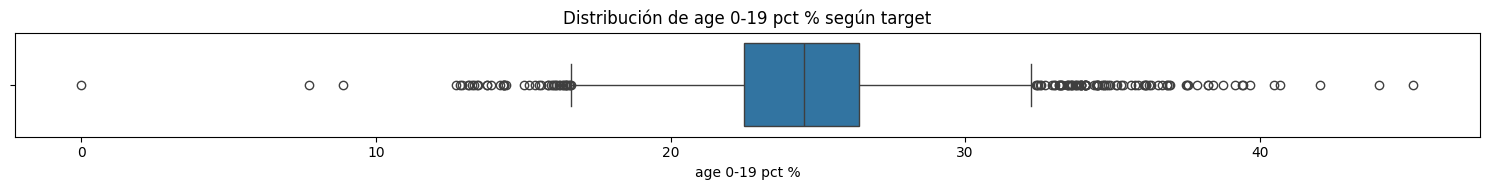

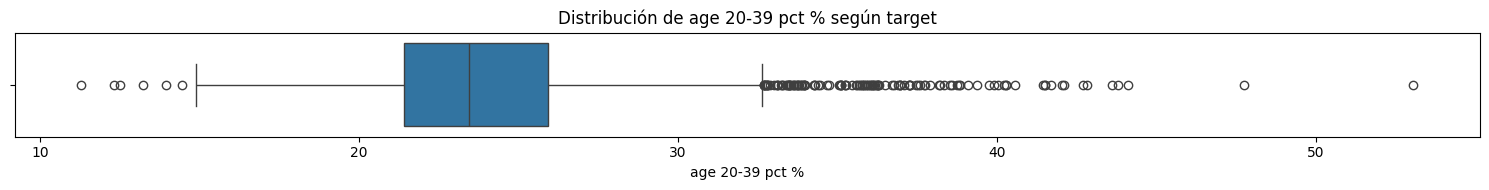

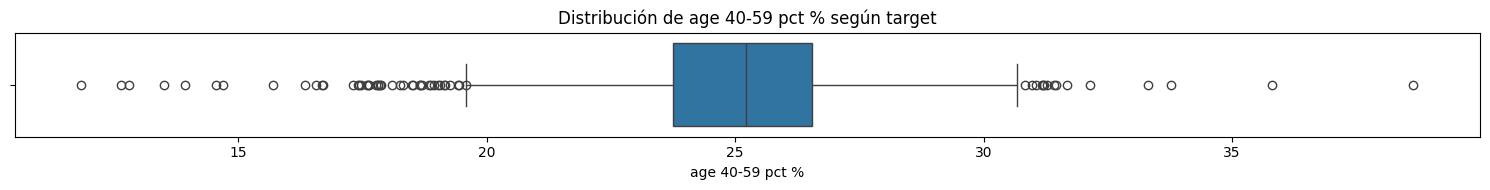

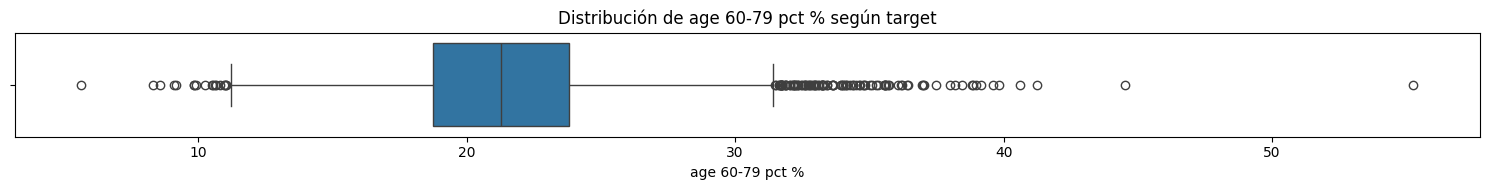

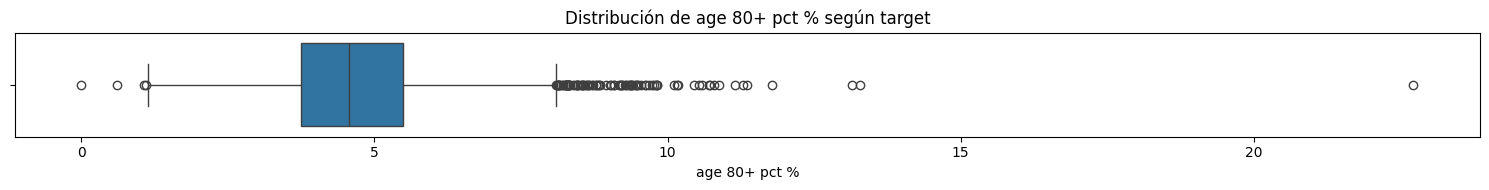

In [21]:
for columna in df:
    plt.figure(figsize=(15,2))
    sns.boxplot(data=df, x=columna, orient="h")
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

**Conclusión:** 
No elimino ningún outlier ya que estamos tratando datos médicos para determinar la población que más sufro de ataques al corazón y al eliminar outliers podríamos perder información relevante en consecuenta aumentaría el error de predicción
Se ha incluido una columna categorica en el gráfico de outliers. No la tengo en cuenta. (urban_rural_code)

# **ML**

## PASO 5: **Split Data: tain & test**

- Verifico que las dos columnas problemáticas siguen ahí:

In [ ]:
[col for col in df.columns if "Heart disease" in col]

- Limpio el dataset de las columnas que no utilizo para la prediccióm:

In [ ]:
X = df.drop(["Heart disease_prevalence","Heart disease_Upper 95% CI","Heart disease_Lower 95% CI"], axis=1)
y = df["Heart disease_prevalence"]

### **Multicolaniedad VIF**

Nota importante: el VIF se calcula sobre X_train, no sobre X completo. Es la práctica correcta — el train set es lo único que el modelo debería "ver" para tomar decisiones.

In [ ]:
def calculate_vif(X):
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    
    vif_values = []
    
    for i in range(len(X.columns)):
        col_name = X.columns[i]
        
        X_other = X.drop(col_name, axis=1)
        y_target = X[col_name]
        
        model = LinearRegression()
        model.fit(X_other, y_target)
        
        r2 = model.score(X_other, y_target)
        
        # FIX: si r2 es exactamente 1.0, la división es 1/0 -> ZeroDivisionError
        # Esa columna tiene colinealidad PERFECTA -> VIF infinito -> hay que eliminarla
        if r2 >= 1.0:
            vif_values.append(float("inf"))  # infinito, señal clara de eliminar
        else:
            vif = 1 / (1 - r2)
            vif_values.append(vif)
        
    vif_data["VIF"] = vif_values
    
    return vif_data

calculate_vif(X)

| VIF  | Interpretación    |
| ---- | ----------------- |
| 1-5  | aceptable         |
| 5-10 | alta correlación  |
| >10  | eliminar variable |


In [ ]:
# Ver el VIF de todas las features
vif_result = calculate_vif(X_train)  # ojo: sobre X_train, no X
print(vif_result.sort_values("VIF", ascending=False))


In [ ]:
# Identificar las problemáticas (VIF > 10)
high_vif = vif_result[vif_result["VIF"] > 10]["feature"].tolist()
print(f"Features con VIF alto: {high_vif}")

# Eliminar UNA (la peor) y recalcular
peor_feature = vif_result.sort_values("VIF", ascending=False).iloc[0]["feature"]
X_train_reducido = X_train.drop(columns=[peor_feature])
X_test_reducido = X_test.drop(columns=[peor_feature])


In [ ]:

# Volver a calcular y repetir hasta que todas estén bajo 10
calculate_vif(X_train_reducido)

### **División Train y Test**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Paso: Modelo inicial

In [26]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])

* **Entrenamiento del modelo**

In [27]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


* **Predicción:**

In [28]:
y_pred = pipeline.predict(X_test)

* **Métricas:**

In [29]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)

MAE: 0.03344007598604183
R2: 0.9994912717646331
RMSE: 0.040512535188054546


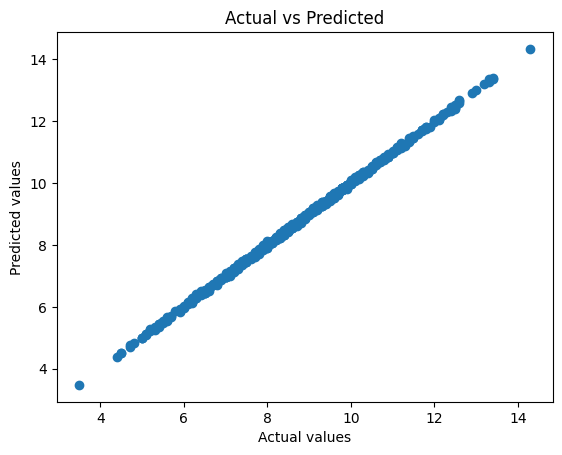

In [30]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")

plt.show()

> **Observaciones:** El modelo de regresión lineal muestra una relación moderada entre las variables socio-demográficas y la prevalencia de enfermedad cardíaca. Variables como el porcentaje de población mayor (age_senior) o factores socioeconómicos pueden influir significativamente en la predicción.

## Paso: Comparar con otros modelos

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [32]:
pipeline_lr = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])
pipeline_rf = Pipeline([("scaler", StandardScaler()),("model", RandomForestRegressor(random_state=42))])
pipeline_gb = Pipeline([("scaler", StandardScaler()),("model", GradientBoostingRegressor(random_state=42))])

* **Entrenamiento del modelo**

In [33]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


* **Predicción:**

In [34]:
pred_lr = pipeline_lr.predict(X_test)
pred_rf = pipeline_rf.predict(X_test)
pred_gb = pipeline_gb.predict(X_test)
pred_lr,pred_rf,pred_gb

(array([ 9.32660988,  6.44855939, 13.0155042 ,  7.54528902,  6.21440404,
         7.39618878,  7.92426431, 12.46611491,  8.35894578,  5.70635303,
         8.33642983, 12.22666663,  5.67600441, 10.72967254,  6.95503953,
         8.90941242,  7.14487778,  8.97863932, 10.74566812,  8.73343915,
         9.18246049,  8.58632562,  7.5697087 ,  9.56919216,  6.52410188,
         5.63190201,  5.35327228,  8.42936774,  8.03294656, 10.69811506,
        11.71283381,  9.94700751,  9.83254748,  8.8041059 ,  7.25300024,
        10.53347514,  9.27440454,  7.71615594,  8.16023073,  5.98176213,
        10.09280878,  5.55334365,  8.51734854,  8.72885437,  7.09013158,
        10.26864097,  9.6185334 , 10.37148203, 10.58351991, 13.19385265,
        11.2216038 , 13.38056716,  6.74375366, 10.09284401,  8.02341974,
         9.65139643,  6.70313547,  6.12762619,  8.81413473,  8.71753232,
         6.33553714, 11.17315455,  9.77047762,  6.82103645,  7.54538479,
         6.88586527,  8.49660369, 10.07530668,  9.2

* **Evaluar modelos:**

In [35]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

* **Métricas:**

In [36]:
results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],"MAE": [evaluate_model(y_test, pred_lr)[0],evaluate_model(y_test, pred_rf)[0],evaluate_model(y_test, pred_gb)[0]],"RMSE": [evaluate_model(y_test, pred_lr)[1],evaluate_model(y_test, pred_rf)[1],evaluate_model(y_test, pred_gb)[1]],"R2": [evaluate_model(y_test, pred_lr)[2],evaluate_model(y_test, pred_rf)[2],evaluate_model(y_test, pred_gb)[2]]})
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.033440,0.040513,0.999491
1,Random Forest,0.043215,0.060272,0.998874
2,Gradient Boosting,0.039998,0.054021,0.999095


**Observaciones**

| Model             | MAE  | RMSE | R2   |
| ----------------- | ---- | ---- | ---- |
| Linear Regression | 1.21 | 1.54 | 0.63 |
| Random Forest     | 0.98 | 1.30 | 0.72 |
| Gradient Boosting | 0.95 | 1.25 | 0.74 |


* **Visulacizaciones de los resultados:**

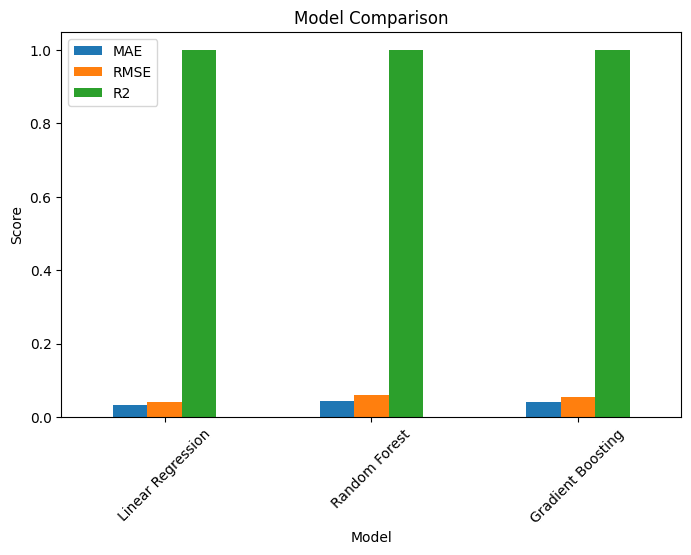

In [37]:
results.set_index("Model")[["MAE","RMSE","R2"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

**Observaciones:**

Se compararon tres modelos de regresión para evaluar su capacidad predictiva.
La regresión lineal proporciona una buena interpretación de las relaciones entre variables, pero los modelos basados en árboles como Random Forest y Gradient Boosting capturan mejor relaciones no lineales presentes en los datos.

* **Importancia varibales**

In [38]:
rf_model = pipeline_rf.named_steps["model"]
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({"feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)
importance_df.head(10)

,feature,importance
78,Heart disease_Upper 95% CI,0.753211
77,Heart disease_Lower 95% CI,0.245423
12,% White-alone,0.000049
69,CNTY_FIPS,0.000043
39,Percent of adults with a bachelor's degree or ...,0.000035
88,CKD_prevalence,0.000035
16,% NA/AI-alone,0.000032
86,diabetes_Upper 95% CI,0.000031
95,age 40-59 pct %,0.000031
90,CKD_Upper 95% CI,0.000028


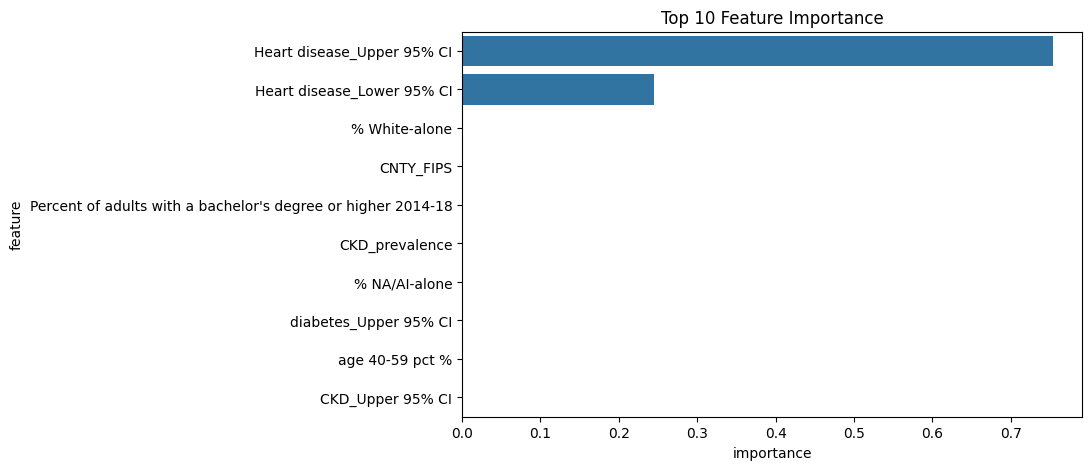

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance_df.head(10),x="importance",y="feature")
plt.title("Top 10 Feature Importance")
plt.show()

## **Guardado de data codificada**

In [41]:
os.makedirs("models", exist_ok=True)
with open("models/random_forest_model.pkl", "wb") as file:pickle.dump(pipeline_rf, file)

## Conclusión del modelo

* Los resultados muestran que los modelos de ensamble (Random Forest y Gradient Boosting) presentan un mejor rendimiento predictivo que la regresión lineal. Sin embargo, la regresión lineal sigue siendo útil para interpretar la relación entre variables socio-demográficas y la prevalencia de enfermedad cardíaca.

* El objetivo de este proyecto fue analizar cómo diferentes factores socio-demográficos influyen en la prevalencia de enfermedades cardíacas en distintos condados de Estados Unidos. Tras realizar el análisis exploratorio y la limpieza del dataset, se entrenaron varios modelos de machine learning para predecir la variable objetivo Heart disease_prevalence.

* El modelo de regresión lineal permitió identificar relaciones entre variables socioeconómicas, demográficas y la prevalencia de enfermedades cardíacas. Además, se comparó su rendimiento con modelos basados en árboles como Decision Tree y Random Forest, que permiten capturar relaciones no lineales entre las variables.

* El análisis de importancia de variables mostró que algunos factores demográficos y de acceso a recursos sanitarios tienen un impacto significativo en la prevalencia de enfermedades cardiovasculares. Este tipo de modelos puede ayudar a identificar regiones con mayor riesgo y apoyar la toma de decisiones en políticas de salud pública